# Motorbike Price Prediction & Price Anomaly Detection

This notebook presents the full analytical and deployment workflow for a used-motorbike pricing project:

1. Business Understanding
2. Environment Setup
3. Load Data
4. Data Understanding
5. Data Preparation
6. Exploratory Data Analysis and Motorbike Segmentation
7. **Price Prediction**
   - scikit-learn
   - Spark ML
8. **Price Anomaly Detection**
   - scikit-learn
   - Spark ML
   - Cross-environment agreement and case studies
9. Export Results
10. Overall Conclusions
11. Streamlit Deployment Preparation

> **Language note:** Vietnamese categorical values, raw column names, listing text, and keyword patterns are intentionally preserved where they are part of the original marketplace data or feature-engineering logic. Narrative documentation and code comments are presented in English.

# 1. Business Understanding

The project addresses two related problems using used-motorbike listing data:

- **Price Prediction:** estimate a reasonable asking price from vehicle and listing attributes.
- **Anomaly Detection:** identify listings whose prices are unusually low or high relative to model expectations and their market segment.

Potential uses include:

- helping sellers estimate a reference price before posting a listing;
- helping moderators prioritize listings with stronger anomaly signals;
- explaining which signals contribute to a suspicious-price decision.

The models provide decision support only. Final pricing and moderation decisions remain with users or reviewers.

# 2. Environment Setup

In [134]:
# Install packages only when they are not already available.

import importlib.util
import subprocess
import sys

packages = {
    "openpyxl": "openpyxl",
    "pyspark": "pyspark>=3.5,<4.1",
}

for module_name, package_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name,
        ])
if importlib.util.find_spec("pyspark") is not None:
    import pyspark
    print("PySpark version:", pyspark.__version__)
else:
    print("PySpark is not available in the local runtime.")

PySpark version: 4.0.3


In [135]:
# Import libraries.

import json
import os
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import shutil

import joblib
import scipy
import sklearn

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    IsolationForest,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SEED = 42
REFERENCE_YEAR = 2025
IN_COLAB = "google.colab" in sys.modules

print("Running in Colab:", IN_COLAB)

Running in Colab: True


# 3. Load Data

In [136]:
# Colab uses /content; the local validation environment uses /mnt/data.

DATA_DIR = Path("/content") if IN_COLAB else Path("/mnt/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "data_motobikes.xlsx"

if not DATA_PATH.exists() and IN_COLAB:
    from google.colab import files

    print("Please upload data_motobikes.xlsx")
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    DATA_PATH = DATA_DIR / uploaded_name

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

print("Data path:", DATA_PATH)

Data path: /content/data_motobikes.xlsx


In [137]:
# Load the raw dataset.

motorbikes_raw = pd.read_excel(DATA_PATH)

print("Shape:", motorbikes_raw.shape)
display(motorbikes_raw.head())

Shape: (7208, 18)


,id,Tiêu đề,Giá,Khoảng giá min,Khoảng giá max,Địa chỉ,Mô tả chi tiết,Thương hiệu,Dòng xe,Năm đăng ký,Số Km đã đi,Tình trạng,Loại xe,Dung tích xe,Xuất xứ,Chính sách bảo hành,Trọng lượng,Href
0,1,"Bán Vespa Sprint 125cc 2024 xanh dương, xe đẹp...",66.000.000 đ,72.53 tr,85.14 tr,"Phường Bến Thành, Quận 1, Tp Hồ Chí Minh",Bán xe #Vespa Sprint 125cc. Mua mới tại #Topco...,Piaggio,Vespa,2024,14000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
1,2,🔥🔥SH 150i Thắng ABS 2019 BSTP Chính Chủ,79.500.000 đ,62.76 tr,73.68 tr,"Phường Tân Định, Quận 1, Tp Hồ Chí Minh","_Bán SH 150i Thắng ABS 2019 Xám Bạc, Úp Team X...",Honda,SH,2019,28000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
2,3,CC Vision Thể Thao 2023 Đen+bộ đèn Demi audi A7,37.000.000 đ,28 tr,32.86 tr,"Phường Cầu Kho, Quận 1, Tp Hồ Chí Minh",Chính chủ bán Vision phiên bản Thể Thao 2023 Đ...,Honda,Vision,2023,12000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
3,4,Vespa Sprint 2019 -125- Đen Đỏ Sport -CHÍNH ...,45.000.000 đ,43.1 tr,50.6 tr,"Phường Bến Nghé, Quận 1, Tp Hồ Chí Minh",XE CÁ NHÂN BÁN - XE DO EM ĐỨNG TÊN CHÍNH C...,Piaggio,Vespa,2019,60000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
4,5,Xe tay ga Yamaha Latte 125 – Đăng ký 2021,23.000.000 đ,17.02 tr,19.98 tr,"Phường Tân Định, Quận 1, Tp Hồ Chí Minh",🛵 Thông tin xe:\n\nDòng xe tay ga cao cấp Yama...,Yamaha,Latte,2021,24000,Đã sử dụng,Tay ga,100 - 175 cc,Nhật Bản,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...


`shape` is reported as `(number of rows, number of columns)`. Each row represents one used-motorbike listing.

# 4. Data Understanding

In [138]:
# Summarize data types, missing values, and unique-value counts.

summary_raw = pd.DataFrame({
    "data_type": motorbikes_raw.dtypes.astype(str),
    "missing_values": motorbikes_raw.isna().sum(),
    "missing_percent": motorbikes_raw.isna().mean() * 100,
    "unique_values": motorbikes_raw.nunique(dropna=False),
})

display(summary_raw)

,data_type,missing_values,missing_percent,unique_values
id,int64,0,0.000,7208
Tiêu đề,object,1,0.014,6840
Giá,object,2,0.028,742
Khoảng giá min,object,202,2.802,1305
Khoảng giá max,object,197,2.733,1349
Địa chỉ,object,41,0.569,311
Mô tả chi tiết,object,0,0.000,7183
Thương hiệu,object,3,0.042,38
Dòng xe,object,3,0.042,196
Năm đăng ký,object,0,0.000,79


In [139]:
# Inspect distributions for low-cardinality columns.

display(motorbikes_raw["Tình trạng"].value_counts())
display(motorbikes_raw["Loại xe"].value_counts())
display(motorbikes_raw["Chính sách bảo hành"].value_counts())
display(motorbikes_raw["Trọng lượng"].value_counts())

,count
Tình trạng,
Đã sử dụng,7207
Mới,1


,count
Loại xe,
Tay ga,3600
Xe số,2189
Tay côn/Moto,1419


,count
Chính sách bảo hành,
Bảo hành hãng,7207


,count
Trọng lượng,
> 50 kg,7207


In [140]:
# Check duplicates by ID and listing URL.

print("Duplicate id:", motorbikes_raw.duplicated(subset="id").sum())
print("Duplicate Href:", motorbikes_raw.duplicated(subset="Href").sum())

Duplicate id: 0
Duplicate Href: 12


In [141]:
# Inspect sample values before cleaning.

columns_to_check = [
    "Giá",
    "Khoảng giá min",
    "Khoảng giá max",
    "Năm đăng ký",
    "Số Km đã đi",
]

display(motorbikes_raw[columns_to_check].head(10))

,Giá,Khoảng giá min,Khoảng giá max,Năm đăng ký,Số Km đã đi
0,66.000.000 đ,72.53 tr,85.14 tr,2024,14000
1,79.500.000 đ,62.76 tr,73.68 tr,2019,28000
2,37.000.000 đ,28 tr,32.86 tr,2023,12000
3,45.000.000 đ,43.1 tr,50.6 tr,2019,60000
4,23.000.000 đ,17.02 tr,19.98 tr,2021,24000
5,7.500.000 đ,7.73 tr,9.08 tr,2018,25000
6,16.000.000 đ,13.83 tr,16.24 tr,2013,80000
7,7.300.000 đ,10.08 tr,11.83 tr,2003,2
8,7.500.000 đ,6.97 tr,8.19 tr,2015,35000
9,33.000.000 đ,27.45 tr,32.22 tr,2020,20000


### Initial Data Observations

- The raw dataset contains **7,208 rows and 18 columns**.
- `Giá` is missing in 2 rows; `Khoảng giá min` in 202 rows; `Khoảng giá max` in 197 rows; and `Địa chỉ` in 41 rows.
- There are no duplicates by `id`, but **12 duplicated `Href` values** are present.
- `Giá` and `Năm đăng ký` are stored as strings and must be converted before analysis.
- `Tình trạng`, `Chính sách bảo hành`, and `Trọng lượng` are nearly constant across rows, so they are not selected as model features.

# 5. Data Preparation

In [142]:
# Convert price strings such as "66.000.000 đ" to 66.0 million VND.

def convert_price_to_million(value):
    if pd.isna(value):
        return np.nan

    digits = re.sub(r"\D", "", str(value))
    if digits == "":
        return np.nan

    return float(digits) / 1_000_000

In [143]:
# Convert price-range strings such as "72.53 tr" to 72.53 million VND.

def convert_range_to_million(value):
    if pd.isna(value):
        return np.nan

    text = str(value).lower().replace(",", ".")
    number = re.search(r"\d+(?:\.\d+)?", text)

    return float(number.group()) if number else np.nan

In [144]:
# Convert registration year to numeric form.

def convert_year(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    if "trước" in text and "1980" in text:
        return 1979

    year = re.search(r"19\d{2}|20\d{2}", text)
    return float(year.group()) if year else np.nan

In [145]:
# Extract district information from the address field.

def extract_district(value):
    if pd.isna(value):
        return "Không rõ"

    text = str(value)

    if re.search(r"Thành phố Thủ Đức|TP\.?\s*Thủ Đức", text, re.I):
        return "Thành phố Thủ Đức"

    pattern = (
        r"Quận\s+(?:\d+|Bình Tân|Bình Thạnh|Gò Vấp|Phú Nhuận|Tân Bình|Tân Phú)"
        r"|Huyện\s+(?:Bình Chánh|Cần Giờ|Củ Chi|Hóc Môn|Nhà Bè)"
    )
    result = re.search(pattern, text, re.I)

    return result.group().title() if result else "Không rõ"

In [146]:
# Rename columns to shorter, code-friendly names.

motorbikes = motorbikes_raw.rename(columns={
    "Tiêu đề": "title",
    "Giá": "price_raw",
    "Khoảng giá min": "provided_min_raw",
    "Khoảng giá max": "provided_max_raw",
    "Địa chỉ": "address",
    "Mô tả chi tiết": "description",
    "Thương hiệu": "brand",
    "Dòng xe": "model",
    "Năm đăng ký": "year_raw",
    "Số Km đã đi": "km",
    "Tình trạng": "condition",
    "Loại xe": "bike_type",
    "Dung tích xe": "capacity",
    "Xuất xứ": "origin",
    "Chính sách bảo hành": "warranty",
    "Trọng lượng": "weight",
    "Href": "href",
}).copy()

In [147]:
# Create numeric columns and derived features.

motorbikes["price_million"] = motorbikes["price_raw"].map(convert_price_to_million)
motorbikes["provided_min_million"] = motorbikes["provided_min_raw"].map(convert_range_to_million)
motorbikes["provided_max_million"] = motorbikes["provided_max_raw"].map(convert_range_to_million)
motorbikes["year"] = motorbikes["year_raw"].map(convert_year)
motorbikes["age"] = REFERENCE_YEAR - motorbikes["year"]
motorbikes["km"] = pd.to_numeric(motorbikes["km"], errors="coerce")
motorbikes["district"] = motorbikes["address"].map(extract_district)
motorbikes["title_length"] = motorbikes["title"].fillna("").astype(str).str.len()
motorbikes["description_length"] = motorbikes["description"].fillna("").astype(str).str.len()

In [148]:
# Clean categorical columns.

categorical_columns = [
    "brand",
    "model",
    "bike_type",
    "capacity",
    "origin",
    "district",
]

for column in categorical_columns:
    motorbikes[column] = (
        motorbikes[column]
        .fillna("Không rõ")
        .astype(str)
        .str.strip()
        .replace("", "Không rõ")
    )

In [149]:
# Correct misplaced values in the engine-capacity field.

valid_capacity_values = {
    "Dưới 50 cc",
    "50 - 100 cc",
    "100 - 175 cc",
    "Trên 175 cc",
    "Không biết rõ",
    "Đang cập nhật",
}

invalid_capacity = ~motorbikes["capacity"].isin(valid_capacity_values)
motorbikes.loc[invalid_capacity, "capacity"] = "Không biết rõ"

print("Corrected engine-capacity values:", invalid_capacity.sum())

Corrected engine-capacity values: 1


In [150]:
# Remove duplicate listings by URL.

rows_before = len(motorbikes)
motorbikes = motorbikes.drop_duplicates(subset="href", keep="first").copy()

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", len(motorbikes))

Rows before duplicate removal: 7208
Rows after duplicate removal: 7196


In [151]:
# Additional feature engineering for the Streamlit deployment model.

# Normalize title and description as strings.
motorbikes["title"] = (
    motorbikes["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

motorbikes["description"] = (
    motorbikes["description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Extremely large mileage values may be placeholders or input errors.
# Keep the row, replace the suspicious value with missing, and retain a flag.
KM_SUSPICIOUS_LIMIT = 500_000

motorbikes["km_suspicious"] = (
    motorbikes["km"].notna()
    & (
        (motorbikes["km"] < 0)
        | (motorbikes["km"] >= KM_SUSPICIOUS_LIMIT)
    )
).astype(int)

motorbikes["km_clean"] = motorbikes["km"].mask(
    motorbikes["km_suspicious"] == 1
)

# Log mileage reduces the influence of very large mileage values.
motorbikes["log_km"] = np.log1p(
    motorbikes["km_clean"].clip(lower=0)
)

# Average mileage per year of vehicle age.
# Replace age = 0 with 1 in the denominator to avoid division by zero.
motorbikes["km_per_year"] = (
    motorbikes["km_clean"]
    / motorbikes["age"].clip(lower=1)
)

# The relationship between vehicle age and price may be nonlinear.
motorbikes["age_squared"] = motorbikes["age"] ** 2

# Create a brand-model interaction feature.
motorbikes["brand_model"] = (
    motorbikes["brand"]
    + " | "
    + motorbikes["model"]
)

# Combine text fields to search for technical keywords.
listing_text = (
    motorbikes["title"]
    + " "
    + motorbikes["description"]
).str.lower()

# Keywords commonly associated with imported or special-origin motorcycles.
motorbikes["is_import_keyword"] = listing_text.str.contains(
    (
        r"nhập\s*(?:ý|khẩu|thái)?"
        r"|hqcn"
        r"|hải\s*quan"
        r"|chính\s*ngạch"
        r"|xe\s*thùng"
        r"|đập\s*thùng"
    ),
    regex=True,
    na=False,
).astype(int)

# ABS often distinguishes variants and may affect price.
motorbikes["is_abs_keyword"] = listing_text.str.contains(
    r"(?<!\w)abs(?!\w)",
    regex=True,
    na=False,
).astype(int)

# Keywords associated with rare or collectible motorcycles.
motorbikes["is_collectible_keyword"] = listing_text.str.contains(
    (
        r"limited"
        r"|sưu\s*tầm"
        r"|nguyên\s*zin"
        r"|full\s*zin"
        r"|đập\s*thùng"
        r"|(?<!\w)yaz(?!\w)"
        r"|xipo"
        r"|vespa\s*946"
    ),
    regex=True,
    na=False,
).astype(int)

# A high-capacity flag helps the model separate large-engine motorcycles.
motorbikes["is_high_capacity"] = (
    motorbikes["capacity"] == "Trên 175 cc"
).astype(int)

engineered_feature_summary = pd.Series({
    "Suspicious mileage": int(motorbikes["km_suspicious"].sum()),
    "Import-keyword matches": int(
        motorbikes["is_import_keyword"].sum()
    ),
    "ABS-keyword matches": int(
        motorbikes["is_abs_keyword"].sum()
    ),
    "Rare/collectible-keyword matches": int(
        motorbikes["is_collectible_keyword"].sum()
    ),
    "Capacity above 175 cc": int(
        motorbikes["is_high_capacity"].sum()
    ),
})

display(engineered_feature_summary.to_frame("Rows"))

,Rows
Suspicious mileage,228
Import-keyword matches,351
ABS-keyword matches,249
Rare/collectible-keyword matches,732
Capacity above 175 cc,312


In [152]:
# Separate anomaly-analysis data from regression-training data.

# Keep all positive prices for anomaly analysis so extreme input errors remain detectable.
anomaly_df = motorbikes[
    motorbikes["price_million"].notna()
    & (motorbikes["price_million"] > 0)
].copy()

# Exclude prices below 1 million or above 1 billion VND from regression training.
model_df = anomaly_df[
    anomaly_df["price_million"].between(1, 1000)
].copy()

cleaning_summary = pd.Series({
    "Raw rows": len(motorbikes_raw),
    "Rows after duplicate removal": len(motorbikes),
    "Rows with missing/zero price": len(motorbikes) - len(anomaly_df),
    "Rows used for anomaly analysis": len(anomaly_df),
    "Rows used for regression training": len(model_df),
    "Positive prices below 1M VND": (anomaly_df["price_million"] < 1).sum(),
    "Prices above 1B VND": (anomaly_df["price_million"] > 1000).sum(),
})

display(cleaning_summary.to_frame("Count"))

,Count
Raw rows,7208
Rows after duplicate removal,7196
Rows with missing/zero price,3
Rows used for anomaly analysis,7193
Rows used for regression training,7141
Positive prices below 1M VND,49
Prices above 1B VND,3


### Feature Selection

- `price_million` is the regression target.
- `provided_min_million` and `provided_max_million` are used only for exploratory checks.
- The provided price ranges are excluded from model features because they are estimates very close to the target and could introduce **data leakage**.
- `condition`, `warranty`, and `weight` are nearly constant and therefore provide little predictive value.

In [153]:
# Save cleaned data for reuse.

OUTPUT_DIR = DATA_DIR / "motorbike_price_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

motorbikes.to_csv(
    OUTPUT_DIR / "motorbikes_cleaned.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/motorbike_price_outputs


# 6. Exploratory Data Analysis and Motorbike Segmentation

## 6.1. Exploratory Data Analysis

In [154]:
# Summarize the price distribution after excluding missing and zero prices.

price_summary = anomaly_df["price_million"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]
)

display(price_summary.to_frame("price_million"))

,price_million
count,"7,193.000"
mean,49.189
std,"1,604.517"
min,0.000
1%,1.235
5%,3.200
10%,4.500
50%,16.500
90%,65.000
95%,93.200


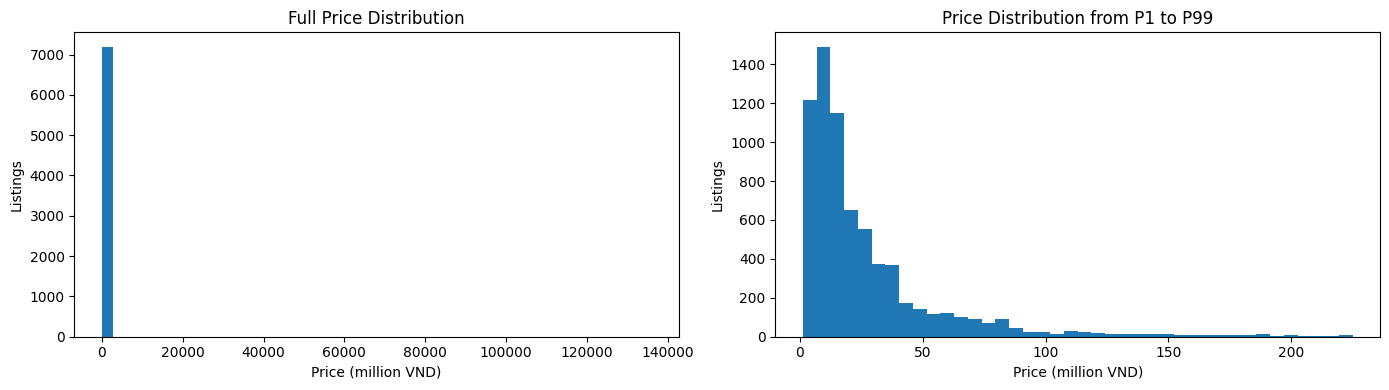

In [155]:
# Plot the full price distribution and the P1-P99 range.

p01 = anomaly_df["price_million"].quantile(0.01)
p99 = anomaly_df["price_million"].quantile(0.99)
price_middle = anomaly_df[
    anomaly_df["price_million"].between(p01, p99)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(anomaly_df["price_million"], bins=50)
axes[0].set_title("Full Price Distribution")
axes[0].set_xlabel("Price (million VND)")
axes[0].set_ylabel("Listings")

axes[1].hist(price_middle["price_million"], bins=40)
axes[1].set_title("Price Distribution from P1 to P99")
axes[1].set_xlabel("Price (million VND)")
axes[1].set_ylabel("Listings")

plt.tight_layout()
plt.show()

### Price Distribution

- Price is **strongly right-skewed**: the median is **16.5 million VND**, P90 is **65.0 million**, and P99 is **225.0 million**.
- The maximum value is **136,000 million VND**, indicating either a data-entry error or an extreme case.
- The full distribution is therefore stretched heavily to the right; the P1-P99 view better reveals the range containing most listings.
- The regression model is trained only on the 1-1,000 million VND range, while positive prices outside this range are retained for anomaly analysis.

In [156]:
# Summarize the 10 brands with the most listings.

brand_summary = (
    anomaly_df.groupby("brand")
    .agg(
        number_of_ads=("id", "count"),
        median_price=("price_million", "median"),
    )
    .sort_values("number_of_ads", ascending=False)
    .head(10)
)

display(brand_summary)

,number_of_ads,median_price
brand,,
Honda,4365,19.000
Yamaha,1411,13.500
Piaggio,380,25.000
Suzuki,280,17.000
SYM,256,4.500
Hãng khác,231,6.000
Kawasaki,60,41.000
Kymco,28,8.600
Ducati,16,130.000


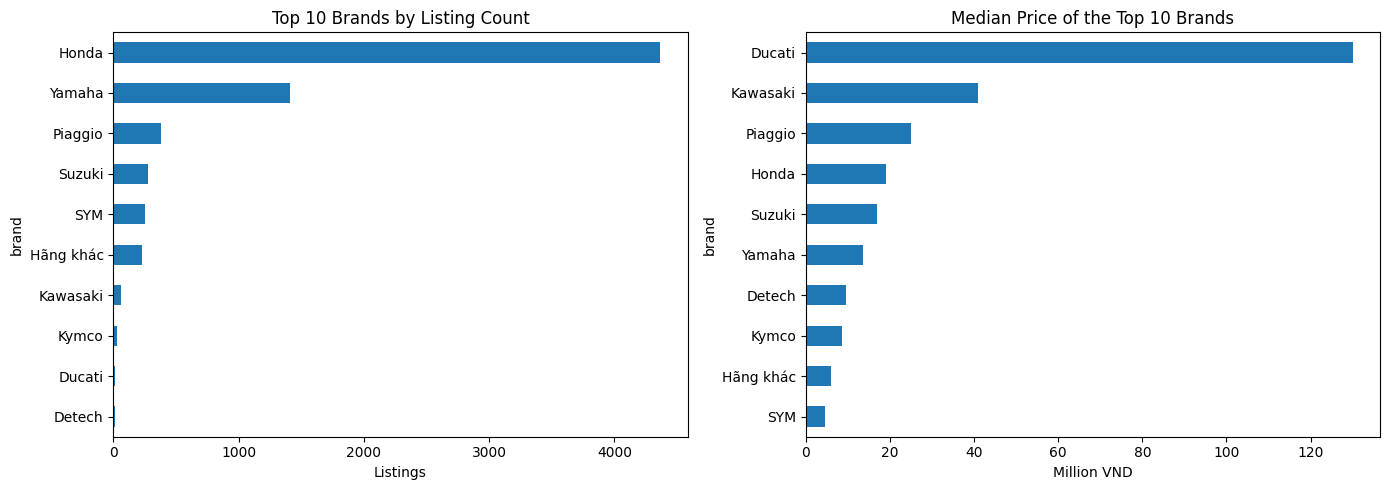

In [157]:
# Plot listing counts and median price by brand.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brand_summary["number_of_ads"].sort_values().plot(
    kind="barh",
    ax=axes[0],
)
axes[0].set_title("Top 10 Brands by Listing Count")
axes[0].set_xlabel("Listings")

brand_summary["median_price"].sort_values().plot(
    kind="barh",
    ax=axes[1],
)
axes[1].set_title("Median Price of the Top 10 Brands")
axes[1].set_xlabel("Million VND")

plt.tight_layout()
plt.show()

### Brand-Level Observations

- **Honda** has the largest number of listings with **4,365 records** and a median price of **19.0 million VND**.
- Yamaha ranks second by listing count but has a lower median price than Honda.
- Ducati and Kawasaki have fewer listings but substantially higher median prices.
- These differences in both volume and price support the use of market segmentation rather than one universal price baseline across all brands.

In [158]:
# Inspect the two provided estimated price-range fields.

range_check = anomaly_df[
    ["price_million", "provided_min_million", "provided_max_million"]
].dropna()

train_range_check = range_check[
    range_check["price_million"].between(1, 1000)
]

provided_min_corr = range_check["price_million"].corr(
    range_check["provided_min_million"]
)
provided_max_corr = range_check["price_million"].corr(
    range_check["provided_max_million"]
)

train_min_corr = train_range_check["price_million"].corr(
    train_range_check["provided_min_million"]
)
train_max_corr = train_range_check["price_million"].corr(
    train_range_check["provided_max_million"]
)

within_provided_range = (
    train_range_check["price_million"].between(
        train_range_check["provided_min_million"],
        train_range_check["provided_max_million"],
    )
).mean()

print("Correlation across all positive prices:")
print("- Provided minimum:", provided_min_corr)
print("- Provided maximum:", provided_max_corr)

print("\nCorrelation within the 1-1000M VND training range:")
print("- Provided minimum:", train_min_corr)
print("- Provided maximum:", train_max_corr)
print("- Share of prices inside the provided range:", within_provided_range)

Correlation across all positive prices:
- Provided minimum: 0.0413100186115846
- Provided maximum: 0.041310458828247416

Correlation within the 1-1000M VND training range:
- Provided minimum: 0.7678018291856444
- Provided maximum: 0.7678038949913684
- Share of prices inside the provided range: 0.2817225983004465


### Provided Price-Range Check

- Across all positive-price observations, correlation is only about **0.041** because extreme price errors distort the relationship.
- Within the 1-1,000 million VND training range, correlation rises to about **0.768**, indicating that the provided ranges are strongly related to the target.
- However, only **28.17%** of observed prices fall inside the provided min-max interval.
- More importantly, these values are target-adjacent estimates that may not be available when pricing a new listing. To avoid **data leakage**, they are not used as model features.

## 6.2. Motorbike Segmentation

Segments are derived from the data instead of applying one global rule to every motorbike:

1. prefer `Brand + Model + Registration-Year Band`;
2. if a group is too small, fall back to `Brand + Bike Type`;
3. if it is still too small, use `Bike Type + Engine Capacity`;
4. remaining very small groups are assigned to `Rare Group` (`Nhóm hiếm` in the source data).

The goal is to keep reasonably similar vehicles together while avoiding segments that are too small for stable statistics.

In [159]:
# Bin registration years into broader year bands.

year_bins = [-np.inf, 1999, 2009, 2014, 2019, np.inf]
year_labels = [
    "Trước 2000",
    "2000-2009",
    "2010-2014",
    "2015-2019",
    "2020-2025",
]

anomaly_df["year_band"] = pd.cut(
    anomaly_df["year"],
    bins=year_bins,
    labels=year_labels,
).astype(str)

anomaly_df["year_band"] = anomaly_df["year_band"].replace("nan", "Không rõ")

In [160]:
# Create detailed market segments.

MIN_SEGMENT_SIZE = 24

anomaly_df["segment_detail"] = (
    anomaly_df["brand"]
    + " | "
    + anomaly_df["model"]
    + " | "
    + anomaly_df["year_band"]
)

detail_counts = anomaly_df["segment_detail"].value_counts()
anomaly_df["segment"] = anomaly_df["segment_detail"]

In [161]:
# Merge small groups by brand and bike type.

small_detail = anomaly_df["segment_detail"].map(detail_counts) < MIN_SEGMENT_SIZE

anomaly_df.loc[small_detail, "segment"] = (
    anomaly_df.loc[small_detail, "brand"]
    + " | "
    + anomaly_df.loc[small_detail, "bike_type"]
)

In [162]:
# If still too small, merge by bike type and engine capacity.

segment_counts = anomaly_df["segment"].value_counts()
small_segment = anomaly_df["segment"].map(segment_counts) < MIN_SEGMENT_SIZE

anomaly_df.loc[small_segment, "segment"] = (
    anomaly_df.loc[small_segment, "bike_type"]
    + " | "
    + anomaly_df.loc[small_segment, "capacity"]
)

In [163]:
# Merge remaining very small groups into the source-data rare-group label.

segment_counts = anomaly_df["segment"].value_counts()
small_segment = anomaly_df["segment"].map(segment_counts) < MIN_SEGMENT_SIZE
anomaly_df.loc[small_segment, "segment"] = "Nhóm hiếm"

anomaly_df["segment_size"] = anomaly_df.groupby("segment")["id"].transform("size")
segment_sizes = anomaly_df["segment"].value_counts()

print("Number of segments:", len(segment_sizes))
print("Minimum segment size:", segment_sizes.min())
print("Median segment size:", segment_sizes.median())
print("Maximum segment size:", segment_sizes.max())

display(segment_sizes.head(15).to_frame("Listings"))

Number of segments: 93
Minimum segment size: 24
Median segment size: 51.0
Maximum segment size: 255


,Listings
segment,
Honda | Wave | 2000-2009,255
Honda | Air Blade | 2010-2014,249
Honda | Xe số,203
Honda | Tay côn/Moto,199
Honda | SH | 2015-2019,194
Honda | Tay ga,192
Yamaha | Exciter | 2015-2019,190
Honda | SH | 2020-2025,186
Honda | Wave | 2010-2014,182


### Segmentation Results

- After merging small groups, the dataset contains **93 segments**.
- Each segment contains at least **24 listings**, with a median of **51** and a maximum of **255**.
- Large groups such as Honda Wave, Honda Air Blade, Honda SH, and Yamaha Exciter remain detailed by registration-year band.
- Rare groups are merged more broadly so that medians, MAD, and percentiles are not estimated from extremely small samples.

In [164]:
# Attach segment information to the regression dataset.

segment_columns = ["id", "year_band", "segment", "segment_size"]

model_df = model_df.drop(
    columns=["year_band", "segment", "segment_size"],
    errors="ignore",
)
model_df = model_df.merge(
    anomaly_df[segment_columns],
    on="id",
    how="left",
)

### How Segments Are Used

The project does **not train 93 separate regression models**, because many segments contain only a few dozen observations and separate models would be unstable. Instead:

- the global price model uses attributes such as `brand`, `model`, `bike_type`, `capacity`, and `year/age` to learn differences across vehicle groups;
- residual statistics, MAD, and price percentiles for anomaly detection are calculated **within each segment**;
- this avoids comparing mass-market motorcycles directly with premium or rare motorcycles while preserving enough data for one global regression model.

# 7. Price Prediction

The first modeling task estimates a reference asking price. The workflow is implemented separately in scikit-learn and Spark ML. Within each environment, five regression models are evaluated using MAE, RMSE, and R², with **MAE as the primary model-selection metric**.

## 7.1. Shared Train/Test Split

Ablation experiments and main models use the same train/test split so that results can be compared directly.

In [165]:
# Define feature groups.

numeric_features = [
    "age",
    "km",
    "title_length",
    "description_length",
]

base_categorical_features = [
    "brand",
    "model",
    "bike_type",
    "capacity",
    "origin",
    "district",
]

# Segment is derived during preprocessing and is available at prediction time.
segment_categorical_features = base_categorical_features + ["segment"]

X_all = model_df[numeric_features + segment_categorical_features].copy()
y = model_df["price_million"].copy()

In [166]:
# Create one train/test split and preserve IDs so Spark uses the same test set.

price_groups = pd.qcut(y, q=10, duplicates="drop")

train_index, test_index = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=SEED,
    stratify=price_groups,
)

train_ids = set(model_df.loc[train_index, "id"])
test_ids = set(model_df.loc[test_index, "id"])

X_train_all = X_all.loc[train_index]
X_test_all = X_all.loc[test_index]
y_train = y.loc[train_index]
y_test = y.loc[test_index]

print("Train rows:", len(train_index))
print("Test rows:", len(test_index))

Train rows: 5712
Test rows: 1429


In [167]:
# Build a simple preprocessing pipeline.

def create_preprocessor(categorical_columns, dense_output=True):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=3,
            sparse_output=not dense_output,
        )),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_columns),
    ])


def create_sklearn_pipeline(model, categorical_columns):
    return Pipeline([
        ("preprocessor", create_preprocessor(categorical_columns)),
        ("model", model),
    ])

## 7.2. Ablation: With vs. Without Segment

The Random Forest configuration is held constant in both runs. The only change is whether the engineered `segment` feature is included.

In [168]:
# Random Forest configuration used for the ablation study.

ablation_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=22,
    min_samples_leaf=2,
    max_features=0.8,
    n_jobs=-1,
    random_state=SEED,
)

### Target Transformation

Price is strongly right-skewed and contains some very high-value motorcycles. The target is therefore transformed with `log1p(price)` before training to reduce the influence of extreme values. Predictions are converted back to million VND with `expm1` before MAE, RMSE, and R² are calculated.

In [169]:
# Run the scikit-learn ablation study.

sklearn_ablation_rows = []

for setting_name, categorical_columns in {
    "Without segment": base_categorical_features,
    "With segment": segment_categorical_features,
}.items():
    feature_columns = numeric_features + categorical_columns

    ablation_model = create_sklearn_pipeline(
        clone(ablation_rf),
        categorical_columns,
    )
    ablation_model.fit(
        X_train_all[feature_columns],
        np.log1p(y_train),
    )

    prediction = np.maximum(
        0,
        np.expm1(ablation_model.predict(X_test_all[feature_columns])),
    )

    sklearn_ablation_rows.append({
        "Setting": setting_name,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": mean_squared_error(y_test, prediction) ** 0.5,
        "R2": r2_score(y_test, prediction),
    })

sklearn_ablation_df = pd.DataFrame(sklearn_ablation_rows)
display(sklearn_ablation_df.round(3))

,Setting,MAE,RMSE,R2
0,Without segment,10.206,33.717,0.450
1,With segment,10.151,33.287,0.464


In [170]:
# Select the scikit-learn feature set with lower MAE.

best_ablation_setting = (
    sklearn_ablation_df
    .sort_values("MAE")
    .iloc[0]["Setting"]
)

if best_ablation_setting == "With segment":
    categorical_features = segment_categorical_features
else:
    categorical_features = base_categorical_features

model_features = numeric_features + categorical_features
X_train = X_train_all[model_features]
X_test = X_test_all[model_features]

print("Selected feature set:", best_ablation_setting)

Selected feature set: With segment


### scikit-learn Ablation Results

- Adding `segment` reduces MAE from **10.206** to **10.151 million VND**.
- RMSE also improves from **33.717 to 33.287**, while R² rises from **0.450 to 0.464**.
- The gain is modest but consistent across all three metrics, so `segment` is retained in the scikit-learn feature set.

## 7.3. Traditional Machine Learning — scikit-learn

In [171]:
# Define five regression models.

sklearn_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=16,
        min_samples_leaf=3,
        random_state=SEED,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=22,
        min_samples_leaf=2,
        max_features=0.8,
        n_jobs=-1,
        random_state=SEED,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        loss="huber",
        random_state=SEED,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=150,
        min_samples_leaf=2,
        max_features=0.9,
        n_jobs=-1,
        random_state=SEED,
    ),
}

In [172]:
# Train and evaluate each model in million VND.

sklearn_results = []
sklearn_fitted_models = {}

y_train_log = np.log1p(y_train)

for model_name, estimator in sklearn_models.items():
    start_time = time.time()

    pipeline = create_sklearn_pipeline(
        clone(estimator),
        categorical_features,
    )
    pipeline.fit(X_train, y_train_log)

    prediction = np.maximum(
        0,
        np.expm1(pipeline.predict(X_test)),
    )

    sklearn_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": mean_squared_error(y_test, prediction) ** 0.5,
        "R2": r2_score(y_test, prediction),
        "Seconds": time.time() - start_time,
    })
    sklearn_fitted_models[model_name] = pipeline
    print("Completed:", model_name)

sklearn_results_df = (
    pd.DataFrame(sklearn_results)
    .sort_values(["MAE", "RMSE"])
    .reset_index(drop=True)
)

display(sklearn_results_df.round(3))

best_sklearn_name = sklearn_results_df.loc[0, "Model"]
best_sklearn_model = sklearn_fitted_models[best_sklearn_name]
print("Best scikit-learn model:", best_sklearn_name)

Completed: Linear Regression
Completed: Decision Tree
Completed: Random Forest
Completed: Gradient Boosting
Completed: Extra Trees


,Model,MAE,RMSE,R2,Seconds
0,Random Forest,10.129,33.262,0.465,4.700
1,Extra Trees,10.425,32.745,0.482,8.182
2,Linear Regression,11.363,31.483,0.521,0.145
3,Gradient Boosting,11.796,35.558,0.389,3.359
4,Decision Tree,12.099,36.550,0.354,0.155


Best scikit-learn model: Random Forest


### scikit-learn Model Results

- Using MAE as the primary criterion, **Random Forest** is selected with MAE **10.129 million VND**, RMSE **33.262**, and R² **0.465**.
- Extra Trees and Linear Regression perform better on RMSE/R² in some comparisons but have higher MAE.
- This illustrates that model ranking depends on the evaluation metric; this project prioritizes MAE because it is directly interpretable as average absolute pricing error in million VND.

### 7.3.1. Actual vs. Predicted and Residual Plot

In [173]:
# Build the test-result table for the selected model.

best_prediction = np.maximum(
    0,
    np.expm1(best_sklearn_model.predict(X_test)),
)

sklearn_test_result = model_df.loc[test_index, [
    "id",
    "segment",
    "price_million",
]].copy()

sklearn_test_result["predicted_price"] = best_prediction
sklearn_test_result["residual"] = (
    sklearn_test_result["price_million"]
    - sklearn_test_result["predicted_price"]
)

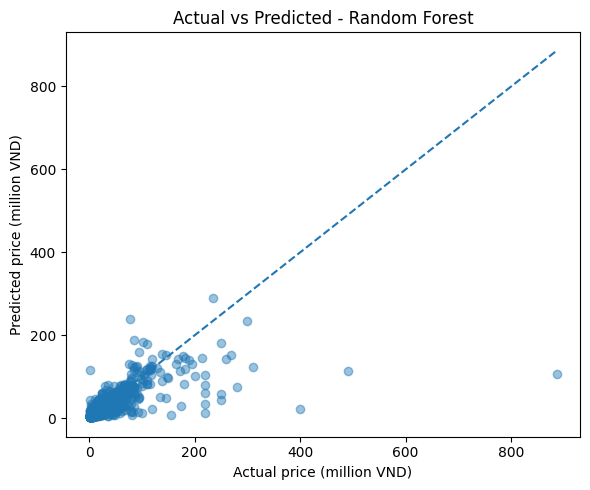

In [174]:
# Actual vs. Predicted.

plt.figure(figsize=(6, 5))
plt.scatter(
    sklearn_test_result["price_million"],
    sklearn_test_result["predicted_price"],
    alpha=0.45,
)

max_price = max(
    sklearn_test_result["price_million"].max(),
    sklearn_test_result["predicted_price"].max(),
)
plt.plot([0, max_price], [0, max_price], linestyle="--")
plt.xlabel("Actual price (million VND)")
plt.ylabel("Predicted price (million VND)")
plt.title(f"Actual vs Predicted - {best_sklearn_name}")
plt.tight_layout()
plt.show()

### Actual vs. Predicted Interpretation

- Most mass-market motorcycles cluster near the diagonal, indicating more accurate predictions in the low- and mid-price ranges.
- Very expensive listings deviate farther from the diagonal, showing a tendency for predictions to regress toward the overall market level.
- Model quality should therefore also be examined by price band and segment rather than relying only on global metrics.

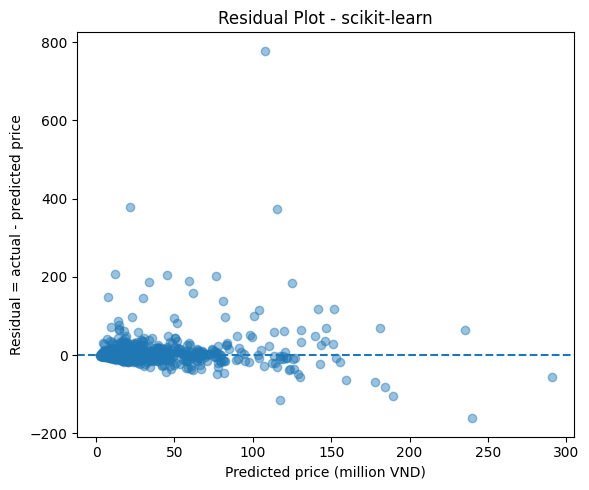

In [175]:
# Residual plot.

plt.figure(figsize=(6, 5))
plt.scatter(
    sklearn_test_result["predicted_price"],
    sklearn_test_result["residual"],
    alpha=0.45,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price (million VND)")
plt.ylabel("Residual = actual - predicted price")
plt.title("Residual Plot - scikit-learn")
plt.tight_layout()
plt.show()

### Residual Plot Interpretation

- Residual spread increases as predicted price rises, indicating non-constant error variance.
- Some very large positive residuals correspond to vehicles whose observed prices are far above model predictions; these are important candidates for anomaly analysis.
- Residuals are not perfectly symmetric around zero. The model remains less reliable for expensive, rare, or incompletely described motorcycles.

### 7.3.2. Error by Price Band and Segment

In [176]:
# MAE by price band.

sklearn_test_result["price_group"] = pd.cut(
    sklearn_test_result["price_million"],
    bins=[-np.inf, 10, 30, 100, np.inf],
    labels=["<10M VND", "10-30M VND", "30-100M VND", ">100M VND"],
)

sklearn_price_group_metrics = (
    sklearn_test_result
    .groupby("price_group", observed=False)
    .apply(lambda group: pd.Series({
        "N": len(group),
        "MAE": mean_absolute_error(
            group["price_million"],
            group["predicted_price"],
        ),
        "RMSE": mean_squared_error(
            group["price_million"],
            group["predicted_price"],
        ) ** 0.5,
    }))
    .reset_index()
)

display(sklearn_price_group_metrics.round(3))

,price_group,N,MAE,RMSE
0,<10M VND,447.000,3.548,7.837
1,10-30M VND,599.000,4.666,7.104
2,30-100M VND,324.000,14.808,23.029
3,>100M VND,59.000,89.764,151.347


### Error by Price Band

- MAE increases substantially with price: **3.548 million VND** below 10 million and **4.666 million** in the 10-30 million range.
- The 30-100 million group has MAE **14.808 million**.
- The >100 million group contains only 59 test rows but reaches MAE **89.764 million**.
- A single global MAE therefore does not fully describe model behavior; premium vehicles remain the main prediction challenge.

In [177]:
# Segment-level error; display only groups with at least 10 test rows.
# Calculate MAE and relative MAE by segment on the test set.

sklearn_segment_metrics = (
    sklearn_test_result.groupby("segment")
    .apply(lambda group: pd.Series({
        "number_of_rows": len(group),
        "median_price": group["price_million"].median(),
        "MAE": mean_absolute_error(
            group["price_million"],
            group["predicted_price"],
        ),
    }))
    .reset_index()
)

sklearn_segment_metrics["relative_MAE"] = (
    sklearn_segment_metrics["MAE"]
    / sklearn_segment_metrics["median_price"].replace(0, np.nan)
)

sklearn_segment_metrics_valid = sklearn_segment_metrics[
    sklearn_segment_metrics["number_of_rows"] >= 10
].copy()

display(
    sklearn_segment_metrics_valid
    .sort_values("number_of_rows", ascending=False)
    .head(12)
    .round(3)
)

,segment,number_of_rows,median_price,MAE,relative_MAE
37,Honda | Wave | 2000-2009,47.000,9.100,4.784,0.526
2,Honda | Air Blade | 2010-2014,45.000,12.000,3.824,0.319
44,Honda | Xe số,45.000,10.000,9.295,0.930
73,Yamaha | Exciter | 2010-2014,43.000,17.500,9.830,0.562
31,Honda | Tay ga,42.000,28.750,15.256,0.531
27,Honda | SH | 2010-2014,38.000,96.500,32.959,0.342
30,Honda | Tay côn/Moto,38.000,25.900,22.154,0.855
28,Honda | SH | 2015-2019,37.000,68.800,11.676,0.170
53,Piaggio | Tay ga,35.000,25.000,8.839,0.354
42,Honda | Winner X | 2020-2025,34.000,23.500,3.240,0.138


In [178]:
# Segments with the highest relative MAE.

display(
    sklearn_segment_metrics_valid
    .sort_values("relative_MAE", ascending=False)
    .head(10)
    .round(3)
)

,segment,number_of_rows,median_price,MAE,relative_MAE
66,Suzuki | Xe số,14.000,7.250,32.251,4.448
64,Suzuki | Tay côn/Moto,31.000,23.000,29.765,1.294
8,Honda | Cub | Trước 2000,19.000,12.000,13.642,1.137
68,Tay côn/Moto | Trên 175 cc,14.000,101.500,114.033,1.123
12,Honda | Dòng khác | 2000-2009,10.000,10.600,11.692,1.103
45,Hãng khác | Dòng khác | 2000-2009,20.000,4.000,4.058,1.014
44,Honda | Xe số,45.000,10.000,9.295,0.930
9,Honda | Dream | 2000-2009,14.000,11.850,10.251,0.865
30,Honda | Tay côn/Moto,38.000,25.900,22.154,0.855
67,Tay côn/Moto | 100 - 175 cc,12.000,14.250,10.563,0.741


### Segment-Level Error — scikit-learn

- Error varies substantially across segments, so global MAE alone is insufficient to describe model quality.
- Common segments such as `Honda | Winner X | 2020-2025` and `Honda | Wave | 2010-2014` show lower relative error.
- Some `Suzuki | Xe số`, `Suzuki | Tay côn/Moto`, and >175 cc groups have high relative MAE because prices are more dispersed and premium/rare observations are limited.
- This supports reporting segment-level error alongside global metrics.

### 7.3.3. Feature Importance

In [179]:
# Extract feature importance or coefficient magnitude.

feature_names = best_sklearn_model[
    "preprocessor"
].get_feature_names_out()

model_step = best_sklearn_model["model"]

if hasattr(model_step, "feature_importances_"):
    importance_values = model_step.feature_importances_
else:
    importance_values = np.abs(model_step.coef_)

sklearn_feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(sklearn_feature_importance.head(15))

,feature,importance
0,categorical__model_SH,0.239
1,numeric__age,0.231
2,categorical__capacity_Trên 175 cc,0.073
3,numeric__km,0.040
4,numeric__description_length,0.039
5,categorical__bike_type_Xe số,0.034
6,numeric__title_length,0.027
7,categorical__bike_type_Tay côn/Moto,0.023
8,categorical__brand_Honda,0.020
9,categorical__model_Exciter,0.019


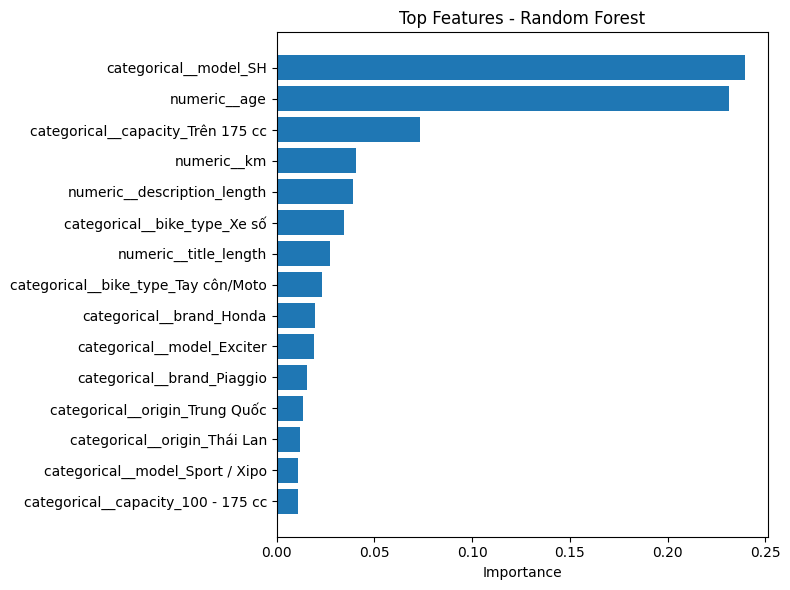

In [180]:
# Plot the 15 most important features.

sklearn_top_features = (
    sklearn_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))
plt.barh(
    sklearn_top_features["feature"],
    sklearn_top_features["importance"],
)
plt.xlabel("Importance")
plt.title(f"Top Features - {best_sklearn_name}")
plt.tight_layout()
plt.show()

### scikit-learn Feature Importance

- The three most important Random Forest features are **SH model membership**, **vehicle age**, and **engine capacity above 175 cc**.
- Mileage, description length, and bike type also contribute, but less strongly.
- Feature importance indicates how much the model uses a feature for prediction; it does not establish causal relationships.

## 7.4. Big Data Environment — Spark ML

In [181]:
# Import Spark ML components.

from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import (
    OneHotEncoder as SparkOneHotEncoder,
    StandardScaler as SparkStandardScaler,
    StringIndexer,
    VectorAssembler,
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.regression import (
    DecisionTreeRegressor as SparkDecisionTreeRegressor,
    GBTRegressor,
    GeneralizedLinearRegression,
    LinearRegression as SparkLinearRegression,
    RandomForestRegressor as SparkRandomForestRegressor,
)
from pyspark.sql import SparkSession, functions as F, types as T

In [182]:
# Create the SparkSession.

spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("Motorbike_Price_Anomaly")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.ui.enabled", "false")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.0.3


In [183]:
# Write cleaned data to CSV for stable Spark ingestion.

all_categorical_features = segment_categorical_features
all_model_features = numeric_features + all_categorical_features

spark_model_pdf = model_df[
    ["id", "price_million"] + all_model_features
].copy()

spark_model_pdf["dataset_split"] = np.where(
    spark_model_pdf["id"].isin(test_ids),
    "test",
    "train",
)

for column in all_categorical_features:
    spark_model_pdf[column] = (
        spark_model_pdf[column]
        .fillna("Không rõ")
        .astype(str)
    )

for column in numeric_features:
    spark_model_pdf[column] = pd.to_numeric(
        spark_model_pdf[column],
        errors="coerce",
    ).fillna(model_df[column].median())

SPARK_MODEL_CSV = OUTPUT_DIR / "spark_model_data.csv"
spark_model_pdf.to_csv(SPARK_MODEL_CSV, index=False)

In [184]:
# Create Spark DataFrames while preserving the shared train/test IDs.

spark_df = (
    spark.createDataFrame(spark_model_pdf)
    .withColumn(
        "label_log",
        F.log(F.col("price_million") + F.lit(1.0)),
    )
)

spark_train = spark_df.filter(F.col("dataset_split") == "train")
spark_test = spark_df.filter(F.col("dataset_split") == "test")

print("Spark train rows:", spark_train.count())
print("Spark test rows:", spark_test.count())

Spark train rows: 5712
Spark test rows: 1429


In [185]:
# Fit a Spark preprocessing pipeline for a set of categorical features.

def fit_spark_preprocessor(train_df, categorical_columns):
    indexers = []
    indexed_columns = []

    for column in categorical_columns:
        indexed_column = f"{column}_index"
        indexers.append(StringIndexer(
            inputCol=column,
            outputCol=indexed_column,
            handleInvalid="keep",
        ))
        indexed_columns.append(indexed_column)

    encoded_columns = [
        f"{column}_encoded"
        for column in categorical_columns
    ]

    encoder = SparkOneHotEncoder(
        inputCols=indexed_columns,
        outputCols=encoded_columns,
        handleInvalid="keep",
    )

    assembler = VectorAssembler(
        inputCols=numeric_features + encoded_columns,
        outputCol="features",
        handleInvalid="keep",
    )

    pipeline = SparkPipeline(
        stages=indexers + [encoder, assembler]
    )

    return pipeline.fit(train_df)

### 7.4.1. Spark Ablation: With vs. Without Segment

In [186]:
# Run the same Random Forest configuration for both feature sets.

spark_ablation_rows = []
spark_ablation_models = {}

for setting_name, categorical_columns in {
    "Without segment": base_categorical_features,
    "With segment": segment_categorical_features,
}.items():
    preprocessing_model = fit_spark_preprocessor(
        spark_train,
        categorical_columns,
    )

    train_prepared = preprocessing_model.transform(spark_train)
    test_prepared = preprocessing_model.transform(spark_test)

    ablation_model = SparkRandomForestRegressor(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        numTrees=12,
        maxDepth=7,
        minInstancesPerNode=2,
        featureSubsetStrategy="0.8",
        seed=SEED,
    ).fit(train_prepared)

    prediction_df = (
        ablation_model
        .transform(test_prepared)
        .withColumn(
            "predicted_price",
            F.greatest(
                F.lit(0.0),
                F.exp(F.col("prediction_log")) - F.lit(1.0),
            ),
        )
    )

    row_result = {"Setting": setting_name}

    for metric_name in ["mae", "rmse", "r2"]:
        evaluator = RegressionEvaluator(
            labelCol="price_million",
            predictionCol="predicted_price",
            metricName=metric_name,
        )
        row_result[metric_name.upper()] = evaluator.evaluate(
            prediction_df
        )

    spark_ablation_rows.append(row_result)
    spark_ablation_models[setting_name] = preprocessing_model

spark_ablation_df = pd.DataFrame(spark_ablation_rows)
display(spark_ablation_df.round(3))

,Setting,MAE,RMSE,R2
0,Without segment,11.785,33.974,0.442
1,With segment,11.604,34.422,0.427


In [187]:
# Select the Spark feature set with lower MAE.

best_spark_ablation_setting = (
    spark_ablation_df
    .sort_values("MAE")
    .iloc[0]["Setting"]
)

if best_spark_ablation_setting == "With segment":
    spark_categorical_features = segment_categorical_features
else:
    spark_categorical_features = base_categorical_features

spark_preprocess_model = fit_spark_preprocessor(
    spark_train,
    spark_categorical_features,
)

spark_train_prepared = spark_preprocess_model.transform(
    spark_train
).cache()
spark_test_prepared = spark_preprocess_model.transform(
    spark_test
).cache()

print("Selected Spark feature set:", best_spark_ablation_setting)

Selected Spark feature set: With segment


### Spark Ablation Results

- Adding `segment` reduces MAE from **11.785** to **11.604 million VND**.
- However, RMSE increases from **33.974 to 34.422** and R² declines from **0.442 to 0.427**.
- Because MAE is the primary selection metric and segment information is also needed for anomaly analysis, Spark continues with the segment feature.

### 7.4.2. Training Five Spark ML Models

In [188]:
# Define five Spark ML models.

spark_models = {
    "Linear Regression": SparkLinearRegression(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        maxIter=80,
        regParam=0.01,
    ),
    "Generalized Linear Regression": GeneralizedLinearRegression(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        family="gaussian",
        link="identity",
        maxIter=40,
        regParam=0.01,
    ),
    "Decision Tree": SparkDecisionTreeRegressor(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        maxDepth=10,
        minInstancesPerNode=3,
        seed=SEED,
    ),
    "Random Forest": SparkRandomForestRegressor(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        numTrees=60,
        maxDepth=12,
        minInstancesPerNode=2,
        featureSubsetStrategy="0.8",
        seed=SEED,
    ),
    "Gradient-Boosted Trees": GBTRegressor(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        maxIter=35,
        maxDepth=5,
        stepSize=0.05,
        seed=SEED,
    ),
}

In [189]:
# Train and evaluate each Spark model.

spark_results = []
spark_fitted_models = {}

for model_name, estimator in spark_models.items():
    start_time = time.time()

    fitted_model = estimator.fit(spark_train_prepared)
    prediction_df = (
        fitted_model
        .transform(spark_test_prepared)
        .withColumn(
            "predicted_price",
            F.greatest(
                F.lit(0.0),
                F.exp(F.col("prediction_log")) - F.lit(1.0),
            ),
        )
    )

    row_result = {"Model": model_name}

    for metric_name in ["mae", "rmse", "r2"]:
        evaluator = RegressionEvaluator(
            labelCol="price_million",
            predictionCol="predicted_price",
            metricName=metric_name,
        )
        row_result[metric_name.upper()] = evaluator.evaluate(
            prediction_df
        )

    row_result["Seconds"] = time.time() - start_time
    spark_results.append(row_result)
    spark_fitted_models[model_name] = fitted_model
    print("Completed:", model_name)

spark_results_df = (
    pd.DataFrame(spark_results)
    .sort_values(["MAE", "RMSE"])
    .reset_index(drop=True)
)

display(spark_results_df.round(3))

best_spark_name = spark_results_df.loc[0, "Model"]
best_spark_model = spark_fitted_models[best_spark_name]
print("Best Spark model:", best_spark_name)

Completed: Linear Regression
Completed: Generalized Linear Regression
Completed: Decision Tree
Completed: Random Forest
Completed: Gradient-Boosted Trees


,Model,MAE,RMSE,R2,Seconds
0,Random Forest,10.543,33.431,0.460,40.651
1,Linear Regression,11.237,30.587,0.548,1.589
2,Generalized Linear Regression,11.237,30.587,0.548,0.431
3,Gradient-Boosted Trees,11.474,33.248,0.466,22.610
4,Decision Tree,11.862,38.708,0.276,1.538


Best Spark model: Random Forest


### Spark ML Results

- By MAE, the selected Spark model is **Random Forest**.
- Random Forest achieves the lowest MAE at **10.543 million VND**.
- Linear Regression has lower RMSE (**30.587 million**) and higher R² (**0.548**).
- Random Forest is retained because MAE was defined as the primary metric, prioritizing lower average absolute pricing error.

### 7.4.3. Actual vs. Predicted and Residual Plot — Spark

In [190]:
# Retrieve test predictions from the selected Spark model.

spark_best_test_prediction = (
    best_spark_model
    .transform(spark_test_prepared)
    .withColumn(
        "predicted_price",
        F.greatest(
            F.lit(0.0),
            F.exp(F.col("prediction_log")) - F.lit(1.0),
        ),
    )
    .withColumn(
        "residual",
        F.col("price_million") - F.col("predicted_price"),
    )
)

spark_test_result = (
    spark_best_test_prediction
    .select(
        "id",
        "segment",
        "price_million",
        "predicted_price",
        "residual",
    )
    .toPandas()
)

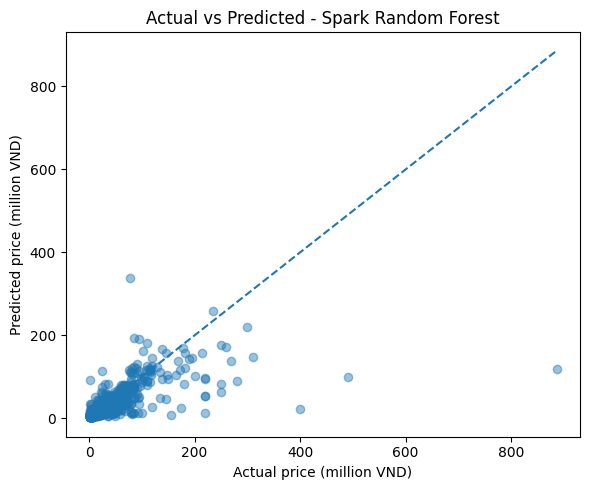

In [191]:
# Actual vs. Predicted — Spark.

plt.figure(figsize=(6, 5))
plt.scatter(
    spark_test_result["price_million"],
    spark_test_result["predicted_price"],
    alpha=0.45,
)

max_price = max(
    spark_test_result["price_million"].max(),
    spark_test_result["predicted_price"].max(),
)
plt.plot([0, max_price], [0, max_price], linestyle="--")
plt.xlabel("Actual price (million VND)")
plt.ylabel("Predicted price (million VND)")
plt.title(f"Actual vs Predicted - Spark {best_spark_name}")
plt.tight_layout()
plt.show()

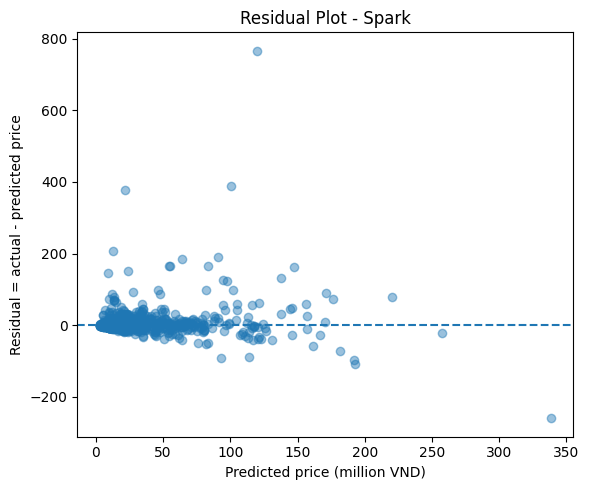

In [192]:
# Residual plot — Spark.

plt.figure(figsize=(6, 5))
plt.scatter(
    spark_test_result["predicted_price"],
    spark_test_result["residual"],
    alpha=0.45,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price (million VND)")
plt.ylabel("Residual = actual - predicted price")
plt.title("Residual Plot - Spark")
plt.tight_layout()
plt.show()

### Spark Plot Interpretation

- The Spark plots show a pattern similar to scikit-learn: low-price vehicles are predicted more accurately, while error grows for expensive motorcycles.
- Several high observed prices fall below the diagonal, indicating underprediction for some rare or premium listings.
- The residual plot contains both very large positive and negative errors, motivating segment-level diagnostics and residual-based anomaly signals.

### 7.4.4. Segment-Level Error — Spark

In [193]:
# Calculate MAE and relative MAE by segment on the Spark test set.

spark_segment_metrics = (
    spark_best_test_prediction
    .withColumn(
        "absolute_error",
        F.abs(F.col("price_million") - F.col("predicted_price")),
    )
    .groupBy("segment")
    .agg(
        F.count("*").alias("number_of_rows"),
        F.expr(
            "percentile_approx(price_million, 0.5, 10000)"
        ).alias("median_price"),
        F.avg("absolute_error").alias("MAE"),
    )
    .withColumn(
        "relative_MAE",
        F.col("MAE") / F.col("median_price"),
    )
    .filter(F.col("number_of_rows") >= 10)
)

display(
    spark_segment_metrics
    .orderBy(F.col("MAE").desc())
    .limit(12)
    .toPandas()
    .round(3)
)

display(
    spark_segment_metrics
    .orderBy(F.col("relative_MAE").desc())
    .limit(10)
    .toPandas()
    .round(3)
)

,segment,number_of_rows,median_price,MAE,relative_MAE
0,Tay côn/Moto | Trên 175 cc,14,99.999,117.059,1.171
1,Suzuki | Tay côn/Moto,31,23.000,32.440,1.410
2,Suzuki | Xe số,14,6.500,30.146,4.638
3,Honda | SH | 2010-2014,38,95.000,29.735,0.313
4,Honda | Tay côn/Moto,38,25.000,23.442,0.938
5,Yamaha | Tay côn/Moto,14,28.000,19.077,0.681
6,Honda | Tay ga,42,25.000,18.352,0.734
7,Honda | SH | 2000-2009,16,45.000,16.351,0.363
8,Honda | SH | 2020-2025,29,83.000,13.702,0.165
9,Honda | Cub | Trước 2000,19,12.000,13.640,1.137


,segment,number_of_rows,median_price,MAE,relative_MAE
0,Suzuki | Xe số,14,6.500,30.146,4.638
1,Honda | Dream | 2000-2009,14,6.700,11.312,1.688
2,Suzuki | Tay côn/Moto,31,23.000,32.440,1.410
3,Honda | Dòng khác | 2000-2009,10,10.200,12.016,1.178
4,Tay côn/Moto | Trên 175 cc,14,99.999,117.059,1.171
5,Honda | Cub | Trước 2000,19,12.000,13.640,1.137
6,Hãng khác | Dòng khác | 2000-2009,20,4.000,4.326,1.081
7,Honda | Tay côn/Moto,38,25.000,23.442,0.938
8,Honda | Xe số,45,10.000,8.975,0.898
9,Tay côn/Moto | 100 - 175 cc,12,13.000,11.241,0.865


### Spark Segment-Level Error

- Error differs substantially across segments. `Tay côn/Moto | Trên 175 cc` has the highest MAE at roughly 117 million VND, indicating instability for high-capacity motorcycles with a wide price range.
- `Suzuki | Xe số` has the highest relative MAE (4.638), meaning its error is several times the segment median price. Honda SH groups have high absolute MAE but lower relative MAE because their price level is higher.
- Overall, the model performs better in common segments and struggles more with sparse, old, rare, or highly variable-price groups.

### 7.4.5. Spark Random Forest Feature Importance

In [194]:
# Extract feature names from Spark vector metadata.

feature_metadata = spark_train_prepared.schema[
    "features"
].metadata["ml_attr"]["attrs"]

spark_feature_names = {}

for attribute_type in feature_metadata.values():
    for attribute in attribute_type:
        spark_feature_names[attribute["idx"]] = attribute["name"]

spark_rf_model = spark_fitted_models["Random Forest"]
spark_rf_importance_values = spark_rf_model.featureImportances.toArray()

spark_feature_importance = pd.DataFrame({
    "feature": [
        spark_feature_names[index]
        for index in range(len(spark_rf_importance_values))
    ],
    "importance": spark_rf_importance_values,
}).sort_values("importance", ascending=False)

display(spark_feature_importance.head(15))

,feature,importance
43,model_encoded_SH,0.270
0,age,0.248
231,capacity_encoded_Trên 175 cc,0.087
226,bike_type_encoded_Xe số,0.039
1,km,0.023
3,description_length,0.022
227,bike_type_encoded_Tay côn/Moto,0.021
4,brand_encoded_Honda,0.021
46,model_encoded_Exciter,0.021
6,brand_encoded_Piaggio,0.018


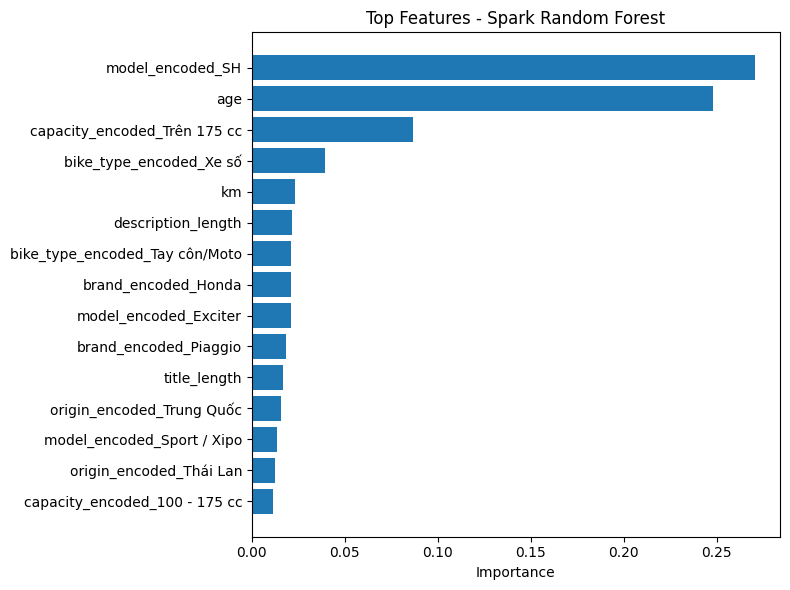

In [195]:
# Plot the 15 most important Spark Random Forest features.

spark_top_features = (
    spark_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))
plt.barh(
    spark_top_features["feature"],
    spark_top_features["importance"],
)
plt.xlabel("Importance")
plt.title("Top Features - Spark Random Forest")
plt.tight_layout()
plt.show()

### Spark Feature Importance

- Spark Random Forest also ranks **SH model membership**, **vehicle age**, and **engine capacity above 175 cc** among the top three features.
- The important feature groups are broadly consistent with scikit-learn, although exact importance values need not match because the tree implementations differ.
- Feature importance provides model interpretability rather than only reporting predictive metrics.

## 7.5. Price Prediction Conclusions

- Ablation shows that `segment` lowers MAE in both environments, although its effect on Spark RMSE/R² is not uniformly positive.
- **Random Forest** is the selected MAE model in both scikit-learn and Spark ML.
- scikit-learn reaches MAE **10.129 million VND**, while Spark reaches **10.543 million VND**. These results are reported independently rather than used to declare one environment universally superior.
- Segment-level error shows that >175 cc motorcycles are among the hardest groups to predict. A deployment interface should therefore expose market-segment context and caution around uncertain cases.

# 8. Price Anomaly Detection

The benchmark anomaly workflow combines **four component signals** and a final composite score:

1. Residual-Z
2. P1-P99
3. P10-P90
4. An unsupervised outlier signal
5. Composite score (0-100) with a top-percentile decision threshold

The scikit-learn benchmark uses Isolation Forest for the unsupervised signal; the Spark benchmark uses KMeans distance.

## 8.1. scikit-learn

### 8.1.1. Out-of-Fold Predictions for Residuals

In [196]:
# Generate 5-fold OOF predictions for regression-training rows.

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
best_model_template = clone(sklearn_models[best_sklearn_name])

oof_prediction_log = cross_val_predict(
    create_sklearn_pipeline(
        best_model_template,
        categorical_features,
    ),
    model_df[model_features],
    np.log1p(model_df["price_million"]),
    cv=cv,
    n_jobs=1,
)

model_df["sklearn_predicted_price"] = np.maximum(
    0,
    np.expm1(oof_prediction_log),
)

In [197]:
# Fit a final model to score positive-price rows outside the regression-training range.

final_sklearn_model = create_sklearn_pipeline(
    clone(sklearn_models[best_sklearn_name]),
    categorical_features,
)
final_sklearn_model.fit(
    model_df[model_features],
    np.log1p(model_df["price_million"]),
)

anomaly_result = anomaly_df.copy()
anomaly_result = anomaly_result.merge(
    model_df[["id", "sklearn_predicted_price"]],
    on="id",
    how="left",
)

missing_prediction = anomaly_result[
    "sklearn_predicted_price"
].isna()

outside_prediction = np.maximum(
    0,
    np.expm1(final_sklearn_model.predict(
        anomaly_result.loc[missing_prediction, model_features]
    )),
)

anomaly_result.loc[
    missing_prediction,
    "sklearn_predicted_price",
] = outside_prediction

anomaly_result["residual"] = (
    anomaly_result["price_million"]
    - anomaly_result["sklearn_predicted_price"]
)

### 8.1.2. Signal 1 — Residual-Z

In [198]:
# Calculate residual median and MAD by segment.

def median_absolute_deviation(series):
    median_value = series.median()
    return np.median(np.abs(series - median_value))

segment_residual_median = (
    anomaly_result
    .groupby("segment")["residual"]
    .median()
    .rename("residual_median")
)

segment_mad = (
    anomaly_result
    .groupby("segment")["residual"]
    .apply(median_absolute_deviation)
    .rename("residual_mad")
)

anomaly_result = anomaly_result.join(
    segment_residual_median,
    on="segment",
)
anomaly_result = anomaly_result.join(
    segment_mad,
    on="segment",
)

In [199]:
# Flag observations when |Residual-Z| >= 3.

global_mad = median_absolute_deviation(anomaly_result["residual"])
fallback_scale = max(1.4826 * global_mad, 1.0)

segment_scale = 1.4826 * anomaly_result["residual_mad"]
segment_scale = segment_scale.where(
    segment_scale > 0,
    fallback_scale,
)

anomaly_result["residual_z"] = (
    anomaly_result["residual"]
    - anomaly_result["residual_median"]
) / segment_scale

anomaly_result["flag_residual_z"] = (
    anomaly_result["residual_z"].abs() >= 3
)

### 8.1.3. Signals 2 and 3 — P1/P99 and P10/P90

In [200]:
# Calculate price percentiles within each segment.

segment_percentiles = (
    anomaly_result
    .groupby("segment")["price_million"]
    .quantile([0.01, 0.10, 0.90, 0.99])
    .unstack()
    .rename(columns={
        0.01: "p01",
        0.10: "p10",
        0.90: "p90",
        0.99: "p99",
    })
)

anomaly_result = anomaly_result.join(
    segment_percentiles,
    on="segment",
)

anomaly_result["flag_minmax"] = (
    (anomaly_result["price_million"] < anomaly_result["p01"])
    | (anomaly_result["price_million"] > anomaly_result["p99"])
)

anomaly_result["flag_common_range"] = (
    (anomaly_result["price_million"] < anomaly_result["p10"])
    | (anomaly_result["price_million"] > anomaly_result["p90"])
)

### 8.1.4. Signal 4 — Isolation Forest with Numeric and Categorical Features

In [201]:
# Isolation Forest uses both numeric/technical and categorical features.

isolation_numeric_features = [
    "age",
    "km",
    "title_length",
    "description_length",
    "sklearn_predicted_price",
    "residual_z",
]

isolation_categorical_features = [
    "brand",
    "model",
    "bike_type",
    "capacity",
    "origin",
    "district",
    "segment",
]

isolation_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        isolation_numeric_features,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=5,
            )),
        ]),
        isolation_categorical_features,
    ),
])

isolation_matrix = isolation_preprocessor.fit_transform(
    anomaly_result[
        isolation_numeric_features
        + isolation_categorical_features
    ]
)

In [202]:
# Fit Isolation Forest and obtain anomaly scores.

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=SEED,
    n_jobs=-1,
)

isolation_forest.fit(isolation_matrix)

anomaly_result["isolation_raw_score"] = -isolation_forest.score_samples(
    isolation_matrix
)
anomaly_result["flag_isolation"] = (
    isolation_forest.predict(isolation_matrix) == -1
)

### 8.1.5. Composite Anomaly Score

In [203]:
# Normalize the four component signals to s1-s4.

anomaly_result["s1_residual"] = (
    anomaly_result["residual_z"].abs() / 6
).clip(0, 1)

anomaly_result["s2_minmax"] = anomaly_result[
    "flag_minmax"
].astype(float)

below_p10 = (
    anomaly_result["p10"] - anomaly_result["price_million"]
).clip(lower=0)

above_p90 = (
    anomaly_result["price_million"] - anomaly_result["p90"]
).clip(lower=0)

common_width = (
    anomaly_result["p90"] - anomaly_result["p10"]
).replace(0, np.nan)

anomaly_result["s3_common_range"] = (
    np.maximum(below_p10, above_p90) / common_width
).fillna(0).clip(0, 1)

isolation_min = anomaly_result["isolation_raw_score"].min()
isolation_max = anomaly_result["isolation_raw_score"].max()

anomaly_result["s4_isolation"] = (
    anomaly_result["isolation_raw_score"] - isolation_min
) / (isolation_max - isolation_min)

In [204]:
# Build the composite score and top-5% threshold.

anomaly_result["sklearn_anomaly_score"] = 100 * (
    0.40 * anomaly_result["s1_residual"]
    + 0.20 * anomaly_result["s2_minmax"]
    + 0.20 * anomaly_result["s3_common_range"]
    + 0.20 * anomaly_result["s4_isolation"]
)

sklearn_anomaly_threshold = anomaly_result[
    "sklearn_anomaly_score"
].quantile(0.95)

anomaly_result["sklearn_is_anomaly"] = (
    anomaly_result["sklearn_anomaly_score"]
    >= sklearn_anomaly_threshold
)

anomaly_result["sklearn_anomaly_type"] = np.where(
    anomaly_result["residual"] < 0,
    "Unusually cheap",
    "Unusually expensive",
)

In [205]:
# Build a scikit-learn table with component flags and reasons.

def create_sklearn_reason(row):
    reasons = []

    if row["flag_residual_z"]:
        reasons.append(f"Residual-Z = {row['residual_z']:.2f}")
    if row["flag_minmax"]:
        reasons.append("Price outside P1-P99")
    if row["flag_common_range"]:
        reasons.append("Price outside P10-P90")
    if row["flag_isolation"]:
        reasons.append("Isolation Forest flag")

    return "; ".join(reasons) if reasons else "High composite score"

component_flags = [
    "flag_residual_z",
    "flag_minmax",
    "flag_common_range",
    "flag_isolation",
]

anomaly_result["sklearn_flag_count"] = anomaly_result[
    component_flags
].sum(axis=1)

anomaly_result["sklearn_reason"] = anomaly_result.apply(
    create_sklearn_reason,
    axis=1,
)

In [206]:
# Summarize scikit-learn anomaly results.

sklearn_anomaly_summary = pd.Series({
    "Top-5% threshold": sklearn_anomaly_threshold,
    "Flagged listings": anomaly_result["sklearn_is_anomaly"].sum(),
    "Unusually cheap": (
        anomaly_result["sklearn_is_anomaly"]
        & (anomaly_result["sklearn_anomaly_type"] == "Unusually cheap")
    ).sum(),
    "Unusually expensive": (
        anomaly_result["sklearn_is_anomaly"]
        & (anomaly_result["sklearn_anomaly_type"] == "Unusually expensive")
    ).sum(),
    "Residual-Z flag": anomaly_result["flag_residual_z"].sum(),
    "P1-P99 flag": anomaly_result["flag_minmax"].sum(),
    "P10-P90 flag": anomaly_result["flag_common_range"].sum(),
    "Isolation Forest flag": anomaly_result["flag_isolation"].sum(),
})

display(sklearn_anomaly_summary.to_frame("Result"))

,Result
Top-5% threshold,49.652
Flagged listings,360.000
Unusually cheap,108.000
Unusually expensive,252.000
Residual-Z flag,580.000
P1-P99 flag,236.000
P10-P90 flag,"1,451.000"
Isolation Forest flag,360.000


- Residual-Z receives weight **0.40** because it directly measures the gap between the observed price and the selected prediction model. The other three signals each receive weight **0.20** to add market-range and structural-outlier information.

- These weights are heuristic because the dataset does not contain ground-truth anomaly labels that could be used to optimize them.

In [207]:
# Inspect the 20 highest scikit-learn anomaly scores.

sklearn_top_anomalies = (
    anomaly_result
    .sort_values("sklearn_anomaly_score", ascending=False)
    [[
        "id",
        "title",
        "segment",
        "price_million",
        "sklearn_predicted_price",
        "flag_residual_z",
        "flag_minmax",
        "flag_common_range",
        "flag_isolation",
        "sklearn_flag_count",
        "sklearn_anomaly_score",
        "sklearn_anomaly_type",
        "sklearn_reason",
    ]]
    .head(20)
)

display(sklearn_top_anomalies.round(3))

,id,title,segment,price_million,sklearn_predicted_price,flag_residual_z,flag_minmax,flag_common_range,flag_isolation,sklearn_flag_count,sklearn_anomaly_score,sklearn_anomaly_type,sklearn_reason
2661,2665,🏍️- #Honda_Africa_Twin_Adventure_Sport 1100 ABS .,Honda | Dòng khác | 2020-2025,490.000,125.756,True,True,True,True,4,98.044,Unusually expensive,Residual-Z = 20.27; Price outside P1-P99; Pric...
1668,1671,Em nhượng lại cho ae 1 xe bền-keng-bs vip 😍,Honda | Wave | 2020-2025,82.000,17.950,True,True,True,True,4,95.948,Unusually expensive,Residual-Z = 17.79; Price outside P1-P99; Pric...
6743,6757,Bán xe mô tô,Honda | Tay côn/Moto,285.000,32.754,True,True,True,True,4,95.500,Unusually expensive,Residual-Z = 22.96; Price outside P1-P99; Pric...
5182,5195,Harley Davidson Streetglide special US chính chủ,Tay côn/Moto | Trên 175 cc,886.000,112.901,True,True,True,True,4,94.993,Unusually expensive,Residual-Z = 7.22; Price outside P1-P99; Price...
3658,3662,"Bán xe moto CB919, đã lên full CB1100, xe rất đep",Honda | Tay côn/Moto,330.000,56.599,True,True,True,True,4,94.801,Unusually expensive,Residual-Z = 24.89; Price outside P1-P99; Pric...
813,816,Xe Thái hàng thùng,Honda | Dream | Trước 2000,110.000,15.498,True,True,True,True,4,94.255,Unusually expensive,Residual-Z = 7.63; Price outside P1-P99; Price...
3988,3992,Honda vtx 1300 cc. Đời 2008. Hải quan chính ngạch,Honda | Dòng khác | 2000-2009,320.000,51.111,True,True,True,True,4,93.434,Unusually expensive,Residual-Z = 45.17; Price outside P1-P99; Pric...
4235,4239,"Bán xe Sh 350i, Máy thái , đăng ký 11/2022",Honda | SH | 2020-2025,"136,000.000",149.302,True,True,True,True,4,93.303,Unusually expensive,Residual-Z = 10770.13; Price outside P1-P99; P...
7093,7109,Xmax 300 chính chủ sang tên,Yamaha | Tay ga,220.000,62.814,True,True,True,True,4,93.102,Unusually expensive,Residual-Z = 27.68; Price outside P1-P99; Pric...
4081,4085,"Xe SH300i mói 99,9% hàng hiếm không có chiếc t...",Honda | SH | 2015-2019,285.000,144.004,True,True,True,False,3,92.733,Unusually expensive,Residual-Z = 14.10; Price outside P1-P99; Pric...


In [208]:
sklearn_flagged = anomaly_result[
    anomaly_result["sklearn_is_anomaly"]
]

display(
    sklearn_flagged["sklearn_flag_count"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_flags")
    .to_frame("number_of_ads")
)

,number_of_ads
number_of_flags,
1,9
2,188
3,146
4,17


### scikit-learn Anomaly Results

- The top-5% threshold is **49.652**, flagging **360** listings for review: **108 unusually cheap** and **252 unusually expensive**.
- Component flags are: Residual-Z **580**, P1-P99 **236**, P10-P90 **1,451**, and Isolation Forest **360**.
- Among the 360 final anomalies, **351 have at least 2 of 4 component flags**; only 9 have one flag. The composite score therefore tends to prioritize cases supported by multiple signals.
- Isolation Forest uses both numeric features and one-hot encoded categorical features, including brand/model/type information and residual-based features.
- P10-P90 is intentionally more sensitive than P1-P99; the final benchmark decision uses the composite score rather than any single flag.

## 8.2. Spark ML

### 8.2.1. Spark Out-of-Fold Predictions

In [209]:
# Prepare all positive-price rows for Spark anomaly detection.

spark_anomaly_pdf = anomaly_result[
    ["id", "title", "href", "price_million"]
    + all_model_features
].copy()

spark_anomaly_pdf["is_model_row"] = (
    spark_anomaly_pdf["price_million"].between(1, 1000)
).astype(int)

for column in all_categorical_features + ["title", "href"]:
    spark_anomaly_pdf[column] = (
        spark_anomaly_pdf[column]
        .fillna("Không rõ")
        .astype(str)
    )

for column in numeric_features:
    spark_anomaly_pdf[column] = pd.to_numeric(
        spark_anomaly_pdf[column],
        errors="coerce",
    ).fillna(model_df[column].median())

SPARK_ANOMALY_CSV = OUTPUT_DIR / "spark_anomaly_data.csv"
spark_anomaly_pdf.to_csv(SPARK_ANOMALY_CSV, index=False)

In [210]:
# Create the Spark DataFrame and preprocess the full anomaly dataset.

spark_anomaly_raw = spark.createDataFrame(spark_anomaly_pdf)

spark_model_all_prepared = spark_preprocess_model.transform(
    spark_df
).cache()

spark_anomaly_prepared = spark_preprocess_model.transform(
    spark_anomaly_raw
).cache()

In [211]:
# Generate 5-fold OOF predictions for regression-training rows.

SPARK_OOF_FOLDS = 5

# Assign folds using a hash of the listing ID.
# This is more randomized than using id % 5,
# while remaining deterministic across runs.
spark_model_with_fold = spark_model_all_prepared.withColumn(
    "oof_fold",
    F.pmod(
        F.xxhash64("id"),
        F.lit(SPARK_OOF_FOLDS),
    ),
)

# Inspect the number of rows in each fold.
spark_model_with_fold.groupBy("oof_fold").count().orderBy(
    "oof_fold"
).show()

spark_oof_predictions = None

for fold_number in range(SPARK_OOF_FOLDS):
    print(
        f"Running fold {fold_number + 1}/{SPARK_OOF_FOLDS}"
    )

    # Fold-specific training data.
    fold_train = spark_model_with_fold.filter(
        F.col("oof_fold") != fold_number
    )

    # Held-out fold used for out-of-fold prediction.
    fold_valid = spark_model_with_fold.filter(
        F.col("oof_fold") == fold_number
    )

    # Train the model on four-fifths of the data.
    fold_model = spark_models[best_spark_name].fit(
        fold_train
    )

    # Predict the remaining one-fifth.
    fold_prediction = (
        fold_model
        .transform(fold_valid)
        .select(
            "id",
            F.greatest(
                F.lit(0.0),
                F.exp(F.col("prediction_log"))
                - F.lit(1.0),
            ).alias("spark_predicted_price"),
        )
    )

    # Combine predictions from all folds.
    if spark_oof_predictions is None:
        spark_oof_predictions = fold_prediction
    else:
        spark_oof_predictions = (
            spark_oof_predictions.unionByName(
                fold_prediction
            )
        )

# Cache because this table is reused in later steps.
spark_oof_predictions = spark_oof_predictions.cache()

print(
    "Spark OOF predictions:",
    spark_oof_predictions.count(),
)

+--------+-----+
|oof_fold|count|
+--------+-----+
|       0| 1408|
|       1| 1468|
|       2| 1404|
|       3| 1437|
|       4| 1424|
+--------+-----+

Running fold 1/5
Running fold 2/5
Running fold 3/5
Running fold 4/5
Running fold 5/5
Spark OOF predictions: 7141


In [212]:
# Verify that every training row has exactly one OOF prediction.

expected_oof_rows = (
    spark_model_all_prepared
    .select("id")
    .distinct()
    .count()
)

actual_oof_rows = (
    spark_oof_predictions
    .select("id")
    .distinct()
    .count()
)

invalid_oof_ids = (
    spark_oof_predictions
    .groupBy("id")
    .count()
    .filter(F.col("count") != 1)
    .count()
)

print("Expected OOF rows:", expected_oof_rows)
print("Actual OOF rows:", actual_oof_rows)
print("IDs without exactly one prediction:", invalid_oof_ids)

if actual_oof_rows != expected_oof_rows:
    raise RuntimeError(
        "OOF prediction count does not match the training data."
    )

if invalid_oof_ids != 0:
    raise RuntimeError(
        "Some IDs do not have exactly one OOF prediction."
    )


# Predict rows outside the regression-training range with a model
# fitted on all valid regression-training data.

spark_best_full_model = spark_models[
    best_spark_name
].fit(
    spark_model_all_prepared
)

spark_outside_predictions = (
    spark_best_full_model
    .transform(
        spark_anomaly_prepared.filter(
            F.col("is_model_row") == 0
        )
    )
    .select(
        "id",
        F.greatest(
            F.lit(0.0),
            F.exp(F.col("prediction_log"))
            - F.lit(1.0),
        ).alias("spark_predicted_price"),
    )
)


# Combine OOF predictions with predictions for rows outside the training range.

spark_all_predictions = (
    spark_oof_predictions.unionByName(
        spark_outside_predictions
    )
)


# Attach predictions to the complete anomaly dataset
# and calculate residuals.

spark_price_prediction = (
    spark_anomaly_prepared
    .join(
        spark_all_predictions,
        on="id",
        how="inner",
    )
    .withColumn(
        "residual",
        F.col("price_million")
        - F.col("spark_predicted_price"),
    )
)


# Validate the final prediction count.

spark_prediction_count = (
    spark_price_prediction.count()
)

if spark_prediction_count != len(anomaly_result):
    raise RuntimeError(
        "Spark prediction count does not match the anomaly dataset."
    )

print("Spark predictions:", spark_prediction_count)

Expected OOF rows: 7141
Actual OOF rows: 7141
IDs without exactly one prediction: 0
Spark predictions: 7193


### 8.2.2. Segment-Based Signals 1-3

In [213]:
# Calculate residual median, MAD, and percentiles by segment.

spark_segment_median = spark_price_prediction.groupBy("segment").agg(
    F.expr(
        "percentile(residual, 0.5)"
    ).alias("residual_median")
)

spark_with_median = spark_price_prediction.join(
    spark_segment_median,
    on="segment",
    how="left",
)

spark_with_deviation = spark_with_median.withColumn(
    "absolute_deviation",
    F.abs(F.col("residual") - F.col("residual_median")),
)

spark_segment_mad = spark_with_deviation.groupBy("segment").agg(
    F.expr(
        "percentile(absolute_deviation, 0.5)"
    ).alias("residual_mad")
)

spark_segment_prices = spark_price_prediction.groupBy("segment").agg(
    F.expr("percentile(price_million, 0.01)").alias("p01"),
    F.expr("percentile(price_million, 0.10)").alias("p10"),
    F.expr("percentile(price_million, 0.90)").alias("p90"),
    F.expr("percentile(price_million, 0.99)").alias("p99"),
)

In [214]:
# Calculate Residual-Z and the three statistical flags.

global_residual_median = spark_price_prediction.approxQuantile(
    "residual",
    [0.5],
    0.001,
)[0]

global_mad = (
    spark_price_prediction
    .withColumn(
        "global_deviation",
        F.abs(F.col("residual") - F.lit(global_residual_median)),
    )
    .approxQuantile("global_deviation", [0.5], 0.001)[0]
)

spark_fallback_scale = max(1.4826 * global_mad, 1.0)

spark_signals = (
    spark_with_deviation
    .join(spark_segment_mad, on="segment", how="left")
    .join(spark_segment_prices, on="segment", how="left")
    .withColumn(
        "residual_scale",
        F.when(
            F.col("residual_mad") > 0,
            1.4826 * F.col("residual_mad"),
        ).otherwise(F.lit(spark_fallback_scale)),
    )
    .withColumn(
        "residual_z",
        (F.col("residual") - F.col("residual_median"))
        / F.col("residual_scale"),
    )
    .withColumn(
        "flag_residual_z",
        F.abs(F.col("residual_z")) >= 3,
    )
    .withColumn(
        "flag_minmax",
        (F.col("price_million") < F.col("p01"))
        | (F.col("price_million") > F.col("p99")),
    )
    .withColumn(
        "flag_common_range",
        (F.col("price_million") < F.col("p10"))
        | (F.col("price_million") > F.col("p90")),
    )
)

### 8.2.3. Signal 4 — KMeans Distance with the Full Feature Vector

In [215]:
# Combine the full feature vector with predicted price and Residual-Z.

kmeans_assembler = VectorAssembler(
    inputCols=[
        "features",
        "spark_predicted_price",
        "residual_z",
    ],
    outputCol="kmeans_raw_features",
    handleInvalid="keep",
)

spark_kmeans_vector = kmeans_assembler.transform(spark_signals)

kmeans_scaler = SparkStandardScaler(
    inputCol="kmeans_raw_features",
    outputCol="kmeans_features",
    withMean=False,
    withStd=True,
).fit(
    spark_kmeans_vector.filter(F.col("is_model_row") == 1)
)

spark_kmeans_scaled = kmeans_scaler.transform(
    spark_kmeans_vector
)

kmeans_model = KMeans(
    k=8,
    seed=SEED,
    featuresCol="kmeans_features",
    predictionCol="cluster",
).fit(
    spark_kmeans_scaled.filter(F.col("is_model_row") == 1)
)

spark_kmeans_scored = kmeans_model.transform(
    spark_kmeans_scaled
)

- Spark uses distance to the assigned KMeans centroid as its unsupervised anomaly signal. Greater distance indicates a rarer observation in feature space.

- `k=8` is an initial experimental configuration rather than a proven optimum. A future modeling study could compare multiple values of `k` using Silhouette Score or other diagnostics.

In [216]:
# Calculate distance to the assigned cluster centroid.

kmeans_centers = [
    center.tolist()
    for center in kmeans_model.clusterCenters()
]

@F.udf(returnType=T.DoubleType())
def distance_to_center(cluster, feature_array):
    center = np.array(kmeans_centers[int(cluster)])
    point = np.array(feature_array)
    return float(np.linalg.norm(point - center))

spark_kmeans_scored = (
    spark_kmeans_scored
    .withColumn(
        "kmeans_feature_array",
        vector_to_array("kmeans_features"),
    )
    .withColumn(
        "kmeans_distance",
        distance_to_center(
            F.col("cluster"),
            F.col("kmeans_feature_array"),
        ),
    )
)

kmeans_distance_threshold = spark_kmeans_scored.approxQuantile(
    "kmeans_distance",
    [0.95],
    0.001,
)[0]

### 8.2.4. Composite Score and Reason Table

In [217]:
# Normalize the four signals and calculate the composite score.

spark_distance_stats = spark_kmeans_scored.agg(
    F.min("kmeans_distance").alias("distance_min"),
    F.max("kmeans_distance").alias("distance_max"),
).first()

distance_min = float(spark_distance_stats["distance_min"])
distance_max = float(spark_distance_stats["distance_max"])
distance_range = max(distance_max - distance_min, 1e-9)

spark_scored = (
    spark_kmeans_scored
    .withColumn(
        "s1_residual",
        F.least(F.abs(F.col("residual_z")) / 6, F.lit(1.0)),
    )
    .withColumn(
        "s2_minmax",
        F.col("flag_minmax").cast("double"),
    )
    .withColumn(
        "outside_distance",
        F.greatest(
            F.greatest(
                F.col("p10") - F.col("price_million"),
                F.lit(0.0),
            ),
            F.greatest(
                F.col("price_million") - F.col("p90"),
                F.lit(0.0),
            ),
        ),
    )
    .withColumn(
        "s3_common_range",
        F.when(
            F.col("p90") > F.col("p10"),
            F.least(
                F.col("outside_distance")
                / (F.col("p90") - F.col("p10")),
                F.lit(1.0),
            ),
        ).otherwise(F.lit(0.0)),
    )
    .withColumn(
        "s4_kmeans",
        (F.col("kmeans_distance") - F.lit(distance_min))
        / F.lit(distance_range),
    )
    .withColumn(
        "flag_kmeans",
        F.col("kmeans_distance") >= kmeans_distance_threshold,
    )
    .withColumn(
        "spark_anomaly_score",
        100 * (
            0.40 * F.col("s1_residual")
            + 0.20 * F.col("s2_minmax")
            + 0.20 * F.col("s3_common_range")
            + 0.20 * F.col("s4_kmeans")
        ),
    )
)

In [218]:
# Apply the final flag, count component flags, and build explanations.

spark_anomaly_threshold = spark_scored.approxQuantile(
    "spark_anomaly_score",
    [0.95],
    0.001,
)[0]

spark_scored = (
    spark_scored
    .withColumn(
        "spark_flag_count",
        F.col("flag_residual_z").cast("int")
        + F.col("flag_minmax").cast("int")
        + F.col("flag_common_range").cast("int")
        + F.col("flag_kmeans").cast("int"),
    )
    .withColumn(
        "spark_is_anomaly",
        F.col("spark_anomaly_score") >= spark_anomaly_threshold,
    )
    .withColumn(
        "spark_anomaly_type",
        F.when(F.col("residual") < 0, "Unusually cheap")
        .otherwise("Unusually expensive"),
    )
    .withColumn(
        "spark_reason",
        F.concat_ws(
            "; ",
            F.when(
                F.col("flag_residual_z"),
                F.format_string(
                    "Residual-Z = %.2f",
                    F.col("residual_z"),
                ),
            ),
            F.when(
                F.col("flag_minmax"),
                F.lit("Price outside P1-P99"),
            ),
            F.when(
                F.col("flag_common_range"),
                F.lit("Price outside P10-P90"),
            ),
            F.when(
                F.col("flag_kmeans"),
                F.lit("KMeans distance in the top 5%"),
            ),
        ),
    )
)

In [219]:
# Build the Spark flag-and-reason table.

spark_anomaly_result = (
    spark_scored
    .select(
        "id",
        "title",
        "href",
        "segment",
        "price_million",
        "spark_predicted_price",
        "residual",
        "residual_z",
        "p01",
        "p10",
        "p90",
        "p99",
        "flag_residual_z",
        "flag_minmax",
        "flag_common_range",
        "flag_kmeans",
        "spark_flag_count",
        "spark_anomaly_score",
        "spark_is_anomaly",
        "spark_anomaly_type",
        "spark_reason",
    )
    .orderBy(F.col("spark_anomaly_score").desc())
    .toPandas()
)

display(spark_anomaly_result.head(20).round(3))

,id,title,href,segment,price_million,spark_predicted_price,residual,residual_z,p01,p10,p90,p99,flag_residual_z,flag_minmax,flag_common_range,flag_kmeans,spark_flag_count,spark_anomaly_score,spark_is_anomaly,spark_anomaly_type,spark_reason
0,4239,"Bán xe Sh 350i, Máy thái , đăng ký 11/2022",https://xe.chotot.com/mua-ban-xe-may-quan-tan-...,Honda | SH | 2020-2025,"136,000.000",143.169,"135,856.831","11,094.061",0.865,66.400,122.900,290.250,True,True,True,True,4,100.000,True,Unusually expensive,Residual-Z = 11094.06; Price outside P1-P99; P...
1,6445,Xe máy,https://xe.chotot.com/mua-ban-xe-may-huyen-bin...,Honda | Air Blade | 2000-2009,"3,500.000",10.284,"3,489.716","1,414.424",4.920,6.500,15.480,316.800,True,True,True,True,4,82.549,True,Unusually expensive,Residual-Z = 1414.42; Price outside P1-P99; Pr...
2,5200,Vento 150cc xe nhập bstp đẹp tứ quý 8888 có Gl...,https://xe.chotot.com/mua-ban-xe-may-thanh-pho...,Tay côn/Moto | 100 - 175 cc,83.500,15.213,68.287,11.007,3.951,5.000,38.200,71.995,True,True,True,True,4,80.731,True,Unusually expensive,Residual-Z = 11.01; Price outside P1-P99; Pric...
3,5233,chính chủ bán xe bmw r nite t,https://xe.chotot.com/mua-ban-xe-may-thanh-pho...,Nhóm hiếm,400.000,16.972,383.028,70.087,1.286,3.910,69.700,374.500,True,True,True,True,4,80.386,True,Unusually expensive,Residual-Z = 70.09; Price outside P1-P99; Pric...
4,7126,"CẦn bán xe ,400cc , odo 600 km",https://xe.chotot.com/mua-ban-xe-may-huyen-nha...,Piaggio | Tay ga,170.000,46.174,123.826,15.301,2.859,6.000,61.350,95.230,True,True,True,True,4,80.369,True,Unusually expensive,Residual-Z = 15.30; Price outside P1-P99; Pric...
5,3230,Bán đồ cỗ Yaz125 2016 Hqcn,https://xe.chotot.com/mua-ban-xe-may-quan-binh...,Yamaha | Tay côn/Moto,"2,000.000",38.122,"1,961.878",162.656,4.885,16.870,76.500,471.600,True,True,True,True,4,80.344,True,Unusually expensive,Residual-Z = 162.66; Price outside P1-P99; Pri...
6,3405,Kẹt tiền bán xe tâm huyết,https://xe.chotot.com/mua-ban-xe-may-quan-binh...,Suzuki | Tay ga,45.600,6.203,39.397,15.007,1.604,2.540,16.600,40.262,True,True,True,True,4,80.311,True,Unusually expensive,Residual-Z = 15.01; Price outside P1-P99; Pric...
7,5195,Harley Davidson Streetglide special US chính chủ,https://xe.chotot.com/mua-ban-xe-may-thanh-pho...,Tay côn/Moto | Trên 175 cc,886.000,78.643,807.357,8.128,12.060,33.700,364.500,761.380,True,True,True,True,4,80.229,True,Unusually expensive,Residual-Z = 8.13; Price outside P1-P99; Price...
8,6215,kẹt tiền bán gấp yaz thùng LƯỚT 800km HQTL sag...,https://xe.chotot.com/mua-ban-xe-may-huyen-bin...,Yamaha | Tay côn/Moto,480.000,86.558,393.442,32.118,4.885,16.870,76.500,471.600,True,True,True,False,3,80.192,True,Unusually expensive,Residual-Z = 32.12; Price outside P1-P99; Pric...
9,1563,Vespa 946 66666,https://xe.chotot.com/mua-ban-xe-may-quan-10-t...,Piaggio | Vespa | 2020-2025,890.000,64.869,825.131,89.893,3.379,45.300,77.900,417.250,True,True,True,False,3,80.184,True,Unusually expensive,Residual-Z = 89.89; Price outside P1-P99; Pric...


In [220]:
# Summarize Spark anomaly results.

spark_anomaly_summary = pd.Series({
    "Top-5% threshold": spark_anomaly_threshold,
    "Flagged listings": spark_anomaly_result["spark_is_anomaly"].sum(),
    "Unusually cheap": (
        spark_anomaly_result["spark_is_anomaly"]
        & (spark_anomaly_result["spark_anomaly_type"] == "Unusually cheap")
    ).sum(),
    "Unusually expensive": (
        spark_anomaly_result["spark_is_anomaly"]
        & (spark_anomaly_result["spark_anomaly_type"] == "Unusually expensive")
    ).sum(),
    "Residual-Z flag": spark_anomaly_result["flag_residual_z"].sum(),
    "P1-P99 flag": spark_anomaly_result["flag_minmax"].sum(),
    "P10-P90 flag": spark_anomaly_result["flag_common_range"].sum(),
    "KMeans flag": spark_anomaly_result["flag_kmeans"].sum(),
})

display(spark_anomaly_summary.to_frame("Result"))

,Result
Top-5% threshold,40.128
Flagged listings,367.000
Unusually cheap,108.000
Unusually expensive,259.000
Residual-Z flag,581.000
P1-P99 flag,236.000
P10-P90 flag,"1,451.000"
KMeans flag,367.000


In [221]:
spark_flagged = spark_anomaly_result[
    spark_anomaly_result["spark_is_anomaly"]
]

display(
    spark_flagged["spark_flag_count"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_flags")
    .to_frame("number_of_ads")
)

,number_of_ads
number_of_flags,
1,6
2,204
3,145
4,12


### Spark Anomaly Results

- Spark uses **5-fold OOF predictions**, so residuals are not calculated from in-sample predictions for the same row.
- The score threshold is **40.128**, producing **367** flagged listings: **108 unusually cheap** and **259 unusually expensive**.
- Component flags are: Residual-Z **581**, P1-P99 **236**, P10-P90 **1,451**, and KMeans **367**. Exact percentile calculations are used to align the statistical range logic with pandas.
- Among the 367 final anomalies, **361 have at least 2 of 4 component flags**. The result table stores each flag and its reason so reviewers receive more than a single anomaly label.

## 8.3. scikit-learn–Spark Agreement and Case Studies

The two environments are not compared to determine a single “winner.” This section measures how consistent their warning lists are in the absence of ground-truth anomaly labels.

In [222]:
# Join results from both environments by listing ID.

agreement_df = anomaly_result[[
    "id",
    "title",
    "segment",
    "price_million",
    "sklearn_predicted_price",
    "sklearn_anomaly_score",
    "sklearn_is_anomaly",
    "sklearn_anomaly_type",
    "sklearn_reason",
]].merge(
    spark_anomaly_result[[
        "id",
        "spark_predicted_price",
        "spark_anomaly_score",
        "spark_is_anomaly",
        "spark_anomaly_type",
        "spark_reason",
    ]],
    on="id",
    how="inner",
)

agreement_table = pd.crosstab(
    agreement_df["sklearn_is_anomaly"],
    agreement_df["spark_is_anomaly"],
    rownames=["scikit-learn"],
    colnames=["Spark"],
)

display(agreement_table)

Spark,False,True
scikit-learn,,
False,6773,60
True,53,307


In [223]:
# Calculate overall agreement and anomaly-set Jaccard similarity.

same_flag = (
    agreement_df["sklearn_is_anomaly"]
    == agreement_df["spark_is_anomaly"]
)

both_anomaly = (
    agreement_df["sklearn_is_anomaly"]
    & agreement_df["spark_is_anomaly"]
)

either_anomaly = (
    agreement_df["sklearn_is_anomaly"]
    | agreement_df["spark_is_anomaly"]
)

agreement_rate = same_flag.mean()

if either_anomaly.sum() > 0:
    anomaly_jaccard = (
        both_anomaly.sum() / either_anomaly.sum()
    )
else:
    anomaly_jaccard = 1.0

agreement_summary = pd.Series({
    "Flagged by both": both_anomaly.sum(),
    "scikit-learn only": (
        agreement_df["sklearn_is_anomaly"]
        & ~agreement_df["spark_is_anomaly"]
    ).sum(),
    "Spark only": (
        ~agreement_df["sklearn_is_anomaly"]
        & agreement_df["spark_is_anomaly"]
    ).sum(),
    "Flagged by neither": (
        ~agreement_df["sklearn_is_anomaly"]
        & ~agreement_df["spark_is_anomaly"]
    ).sum(),
    "Agreement rate": agreement_rate,
    "Jaccard anomaly": anomaly_jaccard,
})

display(agreement_summary.to_frame("Result"))

,Result
Flagged by both,307.000
scikit-learn only,53.000
Spark only,60.000
Flagged by neither,"6,773.000"
Agreement rate,0.984
Jaccard anomaly,0.731


In [224]:
# Select representative case studies from three agreement groups.

def select_cases(mask, number_of_rows=3):
    return (
        agreement_df[mask]
        .assign(
            average_score=lambda frame: (
                frame["sklearn_anomaly_score"]
                + frame["spark_anomaly_score"]
            ) / 2
        )
        .sort_values("average_score", ascending=False)
        .head(number_of_rows)
    )

cases_both = select_cases(
    agreement_df["sklearn_is_anomaly"]
    & agreement_df["spark_is_anomaly"]
)

cases_sklearn_only = select_cases(
    agreement_df["sklearn_is_anomaly"]
    & ~agreement_df["spark_is_anomaly"]
)

cases_spark_only = select_cases(
    ~agreement_df["sklearn_is_anomaly"]
    & agreement_df["spark_is_anomaly"]
)

case_studies = pd.concat([
    cases_both.assign(case_group="Flagged by both"),
    cases_sklearn_only.assign(case_group="scikit-learn only"),
    cases_spark_only.assign(case_group="Spark only"),
], ignore_index=True)

case_columns = [
    "case_group",
    "id",
    "title",
    "segment",
    "price_million",
    "sklearn_predicted_price",
    "spark_predicted_price",
    "sklearn_anomaly_score",
    "spark_anomaly_score",
    "sklearn_reason",
    "spark_reason",
]

display(case_studies[case_columns].round(3))

,case_group,id,title,segment,price_million,sklearn_predicted_price,spark_predicted_price,sklearn_anomaly_score,spark_anomaly_score,sklearn_reason,spark_reason
0,Flagged by both,4239,"Bán xe Sh 350i, Máy thái , đăng ký 11/2022",Honda | SH | 2020-2025,"136,000.000",149.302,143.169,93.303,100.000,Residual-Z = 10770.13; Price outside P1-P99; P...,Residual-Z = 11094.06; Price outside P1-P99; P...
1,Flagged by both,2665,🏍️- #Honda_Africa_Twin_Adventure_Sport 1100 ABS .,Honda | Dòng khác | 2020-2025,490.000,125.756,166.013,98.044,80.129,Residual-Z = 20.27; Price outside P1-P99; Pric...,Residual-Z = 17.77; Price outside P1-P99; Pric...
2,Flagged by both,1671,Em nhượng lại cho ae 1 xe bền-keng-bs vip 😍,Honda | Wave | 2020-2025,82.000,17.950,16.604,95.948,80.084,Residual-Z = 17.79; Price outside P1-P99; Pric...,Residual-Z = 23.77; Price outside P1-P99; Pric...
3,scikit-learn only,3785,"xe dream thái dọn full super dream, như mới,",Honda | Dream | 2000-2009,48.000,19.138,21.800,64.040,38.317,Residual-Z = 5.35; Price outside P10-P90,Residual-Z = 3.33; Price outside P10-P90
4,scikit-learn only,33,Cần bán xe Vespa Primaria 2019 iget,Hãng khác | Dòng khác | 2015-2019,43.000,23.188,25.577,59.953,38.539,Residual-Z = 6.27; Price outside P10-P90,Residual-Z = 3.73; Price outside P10-P90
5,scikit-learn only,5874,"Dọn nhà attila 2013,gtdd bstp,ace về túy tát lại",SYM | Attila | 2010-2014,1.200,6.678,4.502,57.437,38.182,Residual-Z = -3.04; Price outside P1-P99; Pric...,Price outside P1-P99; Price outside P10-P90
6,Spark only,4597,variro 2018 vàng cát od 2500km,Honda | Vario | 2015-2019,85.000,52.764,40.398,49.608,55.940,Residual-Z = 4.02; Price outside P10-P90,Residual-Z = 6.20; Price outside P10-P90
7,Spark only,5431,"Airblade Thái 2009, nguyên zin, biển Q2 cũ",Honda | Air Blade | 2000-2009,30.000,23.143,17.465,45.594,59.320,Residual-Z = 3.18; Price outside P10-P90,Residual-Z = 5.89; Price outside P10-P90
8,Spark only,6798,Honda Airblade 160 date 2024 xám phiên bản Sport,Honda | Air Blade | 2020-2025,62.000,39.621,31.931,47.822,51.251,Price outside P1-P99; Price outside P10-P90,Residual-Z = 3.54; Price outside P1-P99; Price...


### Agreement and Case-Study Interpretation

- The two environments make the same anomaly/non-anomaly decision for **98.43%** of all listings. This rate is high partly because most listings are normal.
- Jaccard similarity is more informative for the anomaly subset: **0.731**, with **307** listings flagged by both systems, **53** only by scikit-learn, and **60** only by Spark.
- Case ID **4239** has an observed price of **136,000 million VND**, while the two models predict only about **149.3** and **143.2 million VND**; both systems rank it as an extreme anomaly.
- Cases flagged by only one environment illustrate that top-5% boundaries and unsupervised models can differ. They are appropriate for manual review rather than evidence that one implementation is definitively correct.

## 8.4. Price Anomaly Detection Conclusions

- Both benchmark environments implement the same overall structure: Residual-Z, P1-P99, P10-P90, an unsupervised signal, and a composite top-percentile score.
- scikit-learn flags **360** listings; Spark flags **367**; **307** appear in the intersection.
- Without ground-truth anomaly labels, agreement, component flags, and case studies are used as reasonableness checks. The output remains a prioritized review list rather than a claim that a listing is definitively incorrect.

# 9. Export Results

In [225]:
# Save the main result tables.

sklearn_ablation_df.to_csv(
    OUTPUT_DIR / "sklearn_segment_ablation.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_ablation_df.to_csv(
    OUTPUT_DIR / "spark_segment_ablation.csv",
    index=False,
    encoding="utf-8-sig",
)

sklearn_results_df.to_csv(
    OUTPUT_DIR / "sklearn_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_results_df.to_csv(
    OUTPUT_DIR / "spark_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

sklearn_segment_metrics.to_csv(
    OUTPUT_DIR / "sklearn_segment_errors.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_segment_metrics.toPandas().to_csv(
    OUTPUT_DIR / "spark_segment_errors.csv",
    index=False,
    encoding="utf-8-sig",
)

sklearn_feature_importance.to_csv(
    OUTPUT_DIR / "sklearn_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_feature_importance.to_csv(
    OUTPUT_DIR / "spark_rf_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

anomaly_result.to_csv(
    OUTPUT_DIR / "sklearn_anomaly_results.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_anomaly_result.to_csv(
    OUTPUT_DIR / "spark_anomaly_results.csv",
    index=False,
    encoding="utf-8-sig",
)

agreement_df.to_csv(
    OUTPUT_DIR / "sklearn_spark_agreement.csv",
    index=False,
    encoding="utf-8-sig",
)

case_studies[case_columns].to_csv(
    OUTPUT_DIR / "anomaly_case_studies.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: /content/motorbike_price_outputs


# 10. Overall Conclusions

- The notebook completes both price prediction and price anomaly analysis in scikit-learn and Spark ML using **7,208 raw listings**, **7,141 regression rows**, and **93 market segments**.
- Random Forest achieves the lowest MAE in both environments: **10.129 million VND** in scikit-learn and **10.543 million VND** in Spark.
- The anomaly benchmark uses out-of-fold predictions, categorical information in the unsupervised models, explicit component flags, explanation tables, and cross-environment agreement analysis.
- The results support reference pricing and review prioritization; they do not automatically prove that a seller entered an incorrect price or justify automatic rejection of a listing.

### Limitations

- The dataset has no ground-truth anomaly labels, so true Precision, Recall, and F1 cannot be reported.
- Some segment-level test groups contain only around 10-20 observations, so their metrics can vary substantially.
- Rare, collectible, high-capacity, and premium motorcycles remain difficult because the data are sparse and prices vary widely.
- The dataset is a Ho Chi Minh City snapshot with a cutoff of **July 1, 2025**; the model should be monitored and retrained as the market changes.

In [226]:
# Create a JSON summary so the README can reference the actual run results.

best_sklearn_row = sklearn_results_df.iloc[0]
best_spark_row = spark_results_df.iloc[0]

sklearn_flagged = anomaly_result[
    anomaly_result["sklearn_is_anomaly"]
]
spark_flagged = spark_anomaly_result[
    spark_anomaly_result["spark_is_anomaly"]
]

# Capture runtime information for the JSON summary.

import subprocess

java_process = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True,
    check=False,
)

java_output = java_process.stderr.strip()

if not java_output:
    java_output = java_process.stdout.strip()

java_version = (
    java_output.splitlines()[0]
    if java_output
    else "Java not found"
)

results_summary = {
    "runtime": {
        "python": sys.version.split()[0],
        "java": java_version,
        "pyspark": pyspark.__version__,
    },
    "raw_rows": int(len(motorbikes_raw)),
    "training_rows": int(len(model_df)),
    "anomaly_rows": int(len(anomaly_result)),
    "segment_count": int(anomaly_df["segment"].nunique()),
    "sklearn_ablation": sklearn_ablation_df.to_dict(orient="records"),
    "spark_ablation": spark_ablation_df.to_dict(orient="records"),
    "sklearn_feature_setting": best_ablation_setting,
    "spark_feature_setting": best_spark_ablation_setting,
    "best_sklearn_model": str(best_sklearn_name),
    "best_sklearn_mae": float(best_sklearn_row["MAE"]),
    "best_sklearn_rmse": float(best_sklearn_row["RMSE"]),
    "best_sklearn_r2": float(best_sklearn_row["R2"]),
    "best_spark_model": str(best_spark_name),
    "best_spark_mae": float(best_spark_row["MAE"]),
    "best_spark_rmse": float(best_spark_row["RMSE"]),
    "best_spark_r2": float(best_spark_row["R2"]),
    "sklearn_segment_errors": sklearn_segment_metrics.to_dict(orient="records"),
    "spark_segment_errors": spark_segment_metrics.toPandas().to_dict(orient="records"),
    "sklearn_top_features": sklearn_feature_importance.head(10).to_dict(orient="records"),
    "spark_top_features": spark_feature_importance.head(10).to_dict(orient="records"),
    "sklearn_anomaly_threshold": float(sklearn_anomaly_threshold),
    "sklearn_anomaly_count": int(len(sklearn_flagged)),
    "sklearn_cheap_count": int((
        sklearn_flagged["sklearn_anomaly_type"] == "Unusually cheap"
    ).sum()),
    "sklearn_expensive_count": int((
        sklearn_flagged["sklearn_anomaly_type"] == "Unusually expensive"
    ).sum()),
    "spark_anomaly_threshold": float(spark_anomaly_threshold),
    "spark_anomaly_count": int(len(spark_flagged)),
    "spark_cheap_count": int((
        spark_flagged["spark_anomaly_type"] == "Unusually cheap"
    ).sum()),
    "spark_expensive_count": int((
        spark_flagged["spark_anomaly_type"] == "Unusually expensive"
    ).sum()),
    "agreement_rate": float(agreement_rate),
    "anomaly_jaccard": float(anomaly_jaccard),
    "both_anomaly": int(both_anomaly.sum()),
    "sklearn_only": int((
        agreement_df["sklearn_is_anomaly"]
        & ~agreement_df["spark_is_anomaly"]
    ).sum()),
    "spark_only": int((
        ~agreement_df["sklearn_is_anomaly"]
        & agreement_df["spark_is_anomaly"]
    ).sum()),
    "sklearn_flag_counts": {
        "residual_z": int(anomaly_result["flag_residual_z"].sum()),
        "p01_p99": int(anomaly_result["flag_minmax"].sum()),
        "p10_p90": int(anomaly_result["flag_common_range"].sum()),
        "isolation_forest": int(anomaly_result["flag_isolation"].sum()),
    },
    "spark_flag_counts": {
        "residual_z": int(spark_anomaly_result["flag_residual_z"].sum()),
        "p01_p99": int(spark_anomaly_result["flag_minmax"].sum()),
        "p10_p90": int(spark_anomaly_result["flag_common_range"].sum()),
        "kmeans": int(spark_anomaly_result["flag_kmeans"].sum()),
    },
    "sklearn_flag_agreement": (
        sklearn_flagged["sklearn_flag_count"]
        .value_counts()
        .sort_index()
        .to_dict()
    ),
    "spark_flag_agreement": (
        spark_flagged["spark_flag_count"]
        .value_counts()
        .sort_index()
        .to_dict()
    ),
    "spark_oof_folds": int(SPARK_OOF_FOLDS),
    "case_studies": case_studies[case_columns].to_dict(orient="records"),
}

SUMMARY_PATH = OUTPUT_DIR / "results_summary.json"

with open(SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(results_summary, file, ensure_ascii=False, indent=2)

print("Python:", sys.version.split()[0])
print("Java:", java_version)
print("PySpark:", pyspark.__version__)
print("Saved summary:", SUMMARY_PATH)

Python: 3.12.13
Java: openjdk version "21.0.11" 2026-04-21
PySpark: 4.0.3
Saved summary: /content/motorbike_price_outputs/results_summary.json


# 11. Streamlit Deployment Preparation

This section extends the benchmark analysis into the artifacts used by the Streamlit application. It introduces a **Premium-aware Random Forest**, deployment-specific feature engineering, 5-fold OOF calibration, segment statistics, Isolation Forest, and exported inference artifacts.

> **Production-status note:** the final Streamlit application adds a three-level review layer (`Normal`, `Needs Manual Review`, `Anomalous`) in `src/inference.py`. The notebook's artifact-validation helper below primarily validates the composite score and hard anomaly threshold; it should not be interpreted as the complete application review-status implementation.

## 11.1. Deployment Features and Pipeline

In [227]:
# Directory containing only artifacts required by the GUI.

DEPLOY_DIR = OUTPUT_DIR / "deployment_artifacts"
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

deployment_numeric_features = [
    "age",
    "age_squared",
    "km_clean",
    "log_km",
    "km_per_year",
    "km_suspicious",
    "title_length",
    "description_length",
    "is_import_keyword",
    "is_abs_keyword",
    "is_collectible_keyword",
    "is_high_capacity",
]

deployment_categorical_features = [
    "brand",
    "model",
    "brand_model",
    "bike_type",
    "capacity",
    "origin",
    "district",
    "segment",
]

deployment_features = (
    deployment_numeric_features
    + deployment_categorical_features
)

print("Deployment numeric features:")
print(deployment_numeric_features)

print("\nDeployment categorical features:")
print(deployment_categorical_features)

Deployment numeric features:
['age', 'age_squared', 'km_clean', 'log_km', 'km_per_year', 'km_suspicious', 'title_length', 'description_length', 'is_import_keyword', 'is_abs_keyword', 'is_collectible_keyword', 'is_high_capacity']

Deployment categorical features:
['brand', 'model', 'brand_model', 'bike_type', 'capacity', 'origin', 'district', 'segment']


In [228]:
# Build a preprocessing pipeline for deployment.

def create_deployment_price_pipeline():
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=3,
                sparse_output=False,
            ),
        ),
    ])

    preprocessor = ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            deployment_numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            deployment_categorical_features,
        ),
    ])

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=24,
        min_samples_leaf=2,
        max_features=0.8,
        n_jobs=-1,
        random_state=SEED,
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def create_price_sample_weights(prices):
    """
    Give higher training weight to motorcycles above 100 million VND.

    <= 30M VND: weight = 1
    30-100M VND: weight = 2
    > 100M VND: weight = 4
    """
    prices = np.asarray(prices)

    return np.select(
        [
            prices > 100,
            prices > 30,
        ],
        [
            4.0,
            2.0,
        ],
        default=1.0,
    )

In [229]:
# Evaluate the deployment model on the current test split.
# Calculate overall metrics and premium-segment metrics.

def evaluate_price_prediction(
    model_name,
    actual,
    predicted,
):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    premium_mask = actual > 100
    common_mask = actual <= 100

    return {
        "Model": model_name,
        "MAE": mean_absolute_error(
            actual,
            predicted,
        ),
        "RMSE": mean_squared_error(
            actual,
            predicted,
        ) ** 0.5,
        "R2": r2_score(
            actual,
            predicted,
        ),
        "Premium rows": int(
            premium_mask.sum()
        ),
        "Premium MAE": mean_absolute_error(
            actual[premium_mask],
            predicted[premium_mask],
        ),
        "Premium RMSE": mean_squared_error(
            actual[premium_mask],
            predicted[premium_mask],
        ) ** 0.5,
        "Common MAE": mean_absolute_error(
            actual[common_mask],
            predicted[common_mask],
        ),
    }

In [230]:
# Predictions from the benchmark model.

baseline_test_prediction = np.maximum(
    0,
    np.expm1(
        best_sklearn_model.predict(
            model_df.loc[test_index, model_features]
        )
    ),
)

# Train the deployment model on the same train/test split.

deployment_eval_model = create_deployment_price_pipeline()

deployment_train_weights = create_price_sample_weights(
    model_df.loc[train_index, "price_million"]
)

deployment_eval_model.fit(
    model_df.loc[
        train_index,
        deployment_features,
    ],
    np.log1p(
        model_df.loc[
            train_index,
            "price_million",
        ]
    ),
    model__sample_weight=deployment_train_weights,
)

deployment_test_prediction = np.maximum(
    0,
    np.expm1(
        deployment_eval_model.predict(
            model_df.loc[
                test_index,
                deployment_features,
            ]
        )
    ),
)

deployment_evaluation = pd.DataFrame([
    evaluate_price_prediction(
        "Benchmark Random Forest",
        y_test,
        baseline_test_prediction,
    ),
    evaluate_price_prediction(
        "Premium-aware Random Forest",
        y_test,
        deployment_test_prediction,
    ),
])

display(
    deployment_evaluation.round(3)
)

,Model,MAE,RMSE,R2,Premium rows,Premium MAE,Premium RMSE,Common MAE
0,Benchmark Random Forest,10.129,33.262,0.465,59,89.764,151.347,6.700
1,Premium-aware Random Forest,9.773,31.649,0.516,59,80.602,142.670,6.722


### Deployment Model Evaluation

The Premium-aware Random Forest improves prediction quality on the current test set:

- MAE decreases from **10.129** to **9.773 million VND**, about a 3.5% improvement.
- RMSE decreases from **33.262** to **31.649 million VND**.
- R² increases from **0.465** to **0.516**.
- MAE for vehicles above 100 million VND decreases from **89.764** to **80.602 million VND**.
- RMSE for that premium group decreases from **151.347** to **142.670 million VND**.

The tradeoff is a small increase in Common MAE from **6.700** to **6.722 million VND**. The deployment model is therefore selected to improve premium-vehicle performance rather than because it is better in every segment.

These figures come from one train/test split, and the >100 million VND group contains only 59 test rows, so premium metrics can still vary across splits.

In [231]:
# Ablation study:
# A. Benchmark: original features + original RF configuration
# B. Original features + new RF configuration
# C. New features + new RF configuration, without sample weighting
# D. New features + new RF configuration, with premium sample weighting

new_rf_configuration = RandomForestRegressor(
    n_estimators=200,
    max_depth=24,
    min_samples_leaf=2,
    max_features=0.8,
    n_jobs=-1,
    random_state=SEED,
)


# B. Keep the original features and change only the Random Forest configuration.
parameter_only_model = create_sklearn_pipeline(
    clone(new_rf_configuration),
    categorical_features,
)

parameter_only_model.fit(
    model_df.loc[
        train_index,
        model_features,
    ],
    np.log1p(
        model_df.loc[
            train_index,
            "price_million",
        ]
    ),
)

parameter_only_prediction = np.maximum(
    0,
    np.expm1(
        parameter_only_model.predict(
            model_df.loc[
                test_index,
                model_features,
            ]
        )
    ),
)


# C. Use the new features without sample weighting.
deployment_unweighted_model = (
    create_deployment_price_pipeline()
)

deployment_unweighted_model.fit(
    model_df.loc[
        train_index,
        deployment_features,
    ],
    np.log1p(
        model_df.loc[
            train_index,
            "price_million",
        ]
    ),
)

deployment_unweighted_prediction = np.maximum(
    0,
    np.expm1(
        deployment_unweighted_model.predict(
            model_df.loc[
                test_index,
                deployment_features,
            ]
        )
    ),
)


# Summarize the four configurations.
deployment_ablation = pd.DataFrame([
    evaluate_price_prediction(
        "A. Original features + original RF",
        y_test,
        baseline_test_prediction,
    ),
    evaluate_price_prediction(
        "B. Original features + new RF",
        y_test,
        parameter_only_prediction,
    ),
    evaluate_price_prediction(
        "C. New features + no weights",
        y_test,
        deployment_unweighted_prediction,
    ),
    evaluate_price_prediction(
        "D. New features + premium weights",
        y_test,
        deployment_test_prediction,
    ),
])

display(
    deployment_ablation.round(3)
)

,Model,MAE,RMSE,R2,Premium rows,Premium MAE,Premium RMSE,Common MAE
0,A. Original features + original RF,10.129,33.262,0.465,59,89.764,151.347,6.700
1,B. Original features + new RF,10.079,33.149,0.469,59,90.230,151.177,6.627
2,C. New features + no weights,9.764,31.986,0.505,59,83.432,145.723,6.591
3,D. New features + premium weights,9.773,31.649,0.516,59,80.602,142.670,6.722


In [232]:
# Calculate changes between successive configurations.
# Negative MAE/RMSE deltas indicate improvement.

deployment_ablation_changes = (
    deployment_ablation.copy()
)

for metric in [
    "MAE",
    "RMSE",
    "Premium MAE",
    "Premium RMSE",
    "Common MAE",
]:
    deployment_ablation_changes[
        f"Δ {metric}"
    ] = (
        deployment_ablation_changes[
            metric
        ].diff()
    )

deployment_ablation_changes[
    "Δ R2"
] = deployment_ablation_changes[
    "R2"
].diff()

display(
    deployment_ablation_changes.round(3)
)

,Model,MAE,RMSE,R2,Premium rows,Premium MAE,Premium RMSE,Common MAE,Δ MAE,Δ RMSE,Δ Premium MAE,Δ Premium RMSE,Δ Common MAE,Δ R2
0,A. Original features + original RF,10.129,33.262,0.465,59,89.764,151.347,6.700,NaN,NaN,NaN,NaN,NaN,NaN
1,B. Original features + new RF,10.079,33.149,0.469,59,90.230,151.177,6.627,-0.050,-0.113,0.466,-0.169,-0.072,0.004
2,C. New features + no weights,9.764,31.986,0.505,59,83.432,145.723,6.591,-0.315,-1.162,-6.798,-5.454,-0.036,0.037
3,D. New features + premium weights,9.773,31.649,0.516,59,80.602,142.670,6.722,0.009,-0.337,-2.830,-3.053,0.131,0.010


### Deployment-Model Ablation

The ablation separates the improvement process into three changes:

1. change the Random Forest configuration;
2. add engineered deployment features;
3. add sample weights that prioritize high-price vehicles.

Comparing A vs. B isolates the configuration change. B vs. C isolates feature engineering. C vs. D isolates premium sample weighting.

The deployment candidate is considered useful only if premium-vehicle error decreases materially without an unacceptable deterioration in overall or common-vehicle performance.

- Changing only the Random Forest configuration from A to B does **not** improve Premium MAE; it increases slightly by 0.466 million VND.
- Adding engineered features from B to C reduces overall MAE by 0.315 million VND and Premium MAE by 6.798 million VND.
- Adding premium sample weights from C to D further reduces Premium MAE by 2.830 million VND and Premium RMSE by 3.053 million VND.
- The tradeoff is a small 0.131 million VND increase in Common MAE.

The results indicate that **feature engineering is the main source of improvement**, while sample weighting provides an additional premium-vehicle gain. The 5-fold OOF evaluation also confirms roughly a **9.3% reduction in Premium MAE** versus the benchmark.

In [233]:
# Evaluate by price band.
# Compare deployment-model error across price bands.

deployment_test_results = pd.DataFrame({
    "actual": y_test,
    "predicted": deployment_test_prediction,
})

deployment_test_results["price_group"] = pd.cut(
    deployment_test_results["actual"],
    bins=[
        -np.inf,
        10,
        30,
        100,
        np.inf,
    ],
    labels=[
        "Below 10M VND",
        "10-30M VND",
        "30-100M VND",
        ">100M VND",
    ],
)

deployment_price_band_metrics = (
    deployment_test_results
    .groupby(
        "price_group",
        observed=True,
    )
    .apply(
        lambda group: pd.Series({
            "Rows": len(group),
            "MAE": mean_absolute_error(
                group["actual"],
                group["predicted"],
            ),
            "RMSE": mean_squared_error(
                group["actual"],
                group["predicted"],
            ) ** 0.5,
        }),
        include_groups=False,
    )
    .reset_index()
)

display(
    deployment_price_band_metrics.round(3)
)

,price_group,Rows,MAE,RMSE
0,Below 10M VND,447.000,3.739,8.614
1,10-30M VND,599.000,4.729,7.423
2,30-100M VND,324.000,14.524,22.516
3,>100M VND,59.000,80.602,142.670


## 11.2. Generate OOF Predictions for the Deployment Model

In [234]:
# Generate OOF predictions manually with sample weights.
# Reset to a continuous 0..n-1 index for KFold.

deployment_training_df = (
    model_df
    .reset_index(drop=True)
    .copy()
)

deployment_oof_prediction = np.full(
    len(deployment_training_df),
    np.nan,
)

deployment_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

for fold_number, (
    fold_train_index,
    fold_valid_index,
) in enumerate(
    deployment_cv.split(deployment_training_df),
    start=1,
):
    fold_model = create_deployment_price_pipeline()

    fold_train = deployment_training_df.iloc[
        fold_train_index
    ]
    fold_valid = deployment_training_df.iloc[
        fold_valid_index
    ]

    fold_weights = create_price_sample_weights(
        fold_train["price_million"]
    )

    fold_model.fit(
        fold_train[deployment_features],
        np.log1p(
            fold_train["price_million"]
        ),
        model__sample_weight=fold_weights,
    )

    fold_prediction = np.maximum(
        0,
        np.expm1(
            fold_model.predict(
                fold_valid[deployment_features]
            )
        ),
    )

    deployment_oof_prediction[
        fold_valid_index
    ] = fold_prediction

    print(
        f"Completed deployment fold "
        f"{fold_number}/5"
    )

assert not np.isnan(
    deployment_oof_prediction
).any()

deployment_training_df[
    "deployment_predicted_price"
] = deployment_oof_prediction

print(
    "OOF rows:",
    len(deployment_training_df),
)

Completed deployment fold 1/5
Completed deployment fold 2/5
Completed deployment fold 3/5
Completed deployment fold 4/5
Completed deployment fold 5/5
OOF rows: 7141


In [235]:
# Join benchmark and deployment OOF predictions by ID.

deployment_oof_comparison = (
    model_df[
        [
            "id",
            "price_million",
            "sklearn_predicted_price",
        ]
    ]
    .merge(
        deployment_training_df[
            [
                "id",
                "deployment_predicted_price",
            ]
        ],
        on="id",
        how="inner",
        validate="one_to_one",
    )
)

assert len(
    deployment_oof_comparison
) == len(model_df)

print(
    "OOF comparison rows:",
    len(deployment_oof_comparison),
)

OOF comparison rows: 7141


In [236]:
# Compare metrics using all OOF predictions.

deployment_oof_evaluation = pd.DataFrame([
    evaluate_price_prediction(
        "Benchmark RF - 5-fold OOF",
        deployment_oof_comparison[
            "price_million"
        ],
        deployment_oof_comparison[
            "sklearn_predicted_price"
        ],
    ),
    evaluate_price_prediction(
        "Premium-aware RF - 5-fold OOF",
        deployment_oof_comparison[
            "price_million"
        ],
        deployment_oof_comparison[
            "deployment_predicted_price"
        ],
    ),
])

display(
    deployment_oof_evaluation.round(3)
)

,Model,MAE,RMSE,R2,Premium rows,Premium MAE,Premium RMSE,Common MAE
0,Benchmark RF - 5-fold OOF,10.110,32.089,0.491,313,89.341,141.381,6.478
1,Premium-aware RF - 5-fold OOF,9.741,30.589,0.538,313,81.032,133.581,6.473


In [237]:
# Evaluate OOF performance by price band.
deployment_oof_comparison[
    "price_group"
] = pd.cut(
    deployment_oof_comparison[
        "price_million"
    ],
    bins=[
        -np.inf,
        10,
        30,
        100,
        np.inf,
    ],
    labels=[
        "Below 10M VND",
        "10-30M VND",
        "30-100M VND",
        ">100M VND",
    ],
)

deployment_oof_band_rows = []

oof_prediction_columns = {
    "Benchmark RF": (
        "sklearn_predicted_price"
    ),
    "Premium-aware RF": (
        "deployment_predicted_price"
    ),
}

for model_name, prediction_column in (
    oof_prediction_columns.items()
):
    for price_group, group in (
        deployment_oof_comparison
        .groupby(
            "price_group",
            observed=True,
        )
    ):
        deployment_oof_band_rows.append({
            "Model": model_name,
            "Price group": price_group,
            "Rows": len(group),
            "MAE": mean_absolute_error(
                group["price_million"],
                group[prediction_column],
            ),
            "RMSE": mean_squared_error(
                group["price_million"],
                group[prediction_column],
            ) ** 0.5,
        })

deployment_oof_price_band_metrics = (
    pd.DataFrame(
        deployment_oof_band_rows
    )
)

display(
    deployment_oof_price_band_metrics
    .round(3)
)

,Model,Price group,Rows,MAE,RMSE
0,Benchmark RF,Below 10M VND,2277,3.476,7.172
1,Benchmark RF,10-30M VND,2933,4.724,8.771
2,Benchmark RF,30-100M VND,1618,13.883,21.585
3,Benchmark RF,>100M VND,313,89.341,141.381
4,Premium-aware RF,Below 10M VND,2277,3.631,7.520
5,Premium-aware RF,10-30M VND,2933,4.646,7.833
6,Premium-aware RF,30-100M VND,1618,13.783,22.070
7,Premium-aware RF,>100M VND,313,81.032,133.581


In [238]:
# Define the rule for retaining the new deployment model.
benchmark_oof_row = (
    deployment_oof_evaluation.iloc[0]
)

premium_oof_row = (
    deployment_oof_evaluation.iloc[1]
)

overall_mae_change_percent = (
    100
    * (
        premium_oof_row["MAE"]
        - benchmark_oof_row["MAE"]
    )
    / benchmark_oof_row["MAE"]
)

premium_mae_change_percent = (
    100
    * (
        premium_oof_row["Premium MAE"]
        - benchmark_oof_row["Premium MAE"]
    )
    / benchmark_oof_row["Premium MAE"]
)

premium_rmse_change_percent = (
    100
    * (
        premium_oof_row["Premium RMSE"]
        - benchmark_oof_row["Premium RMSE"]
    )
    / benchmark_oof_row["Premium RMSE"]
)

# Practical decision rule:
# - Premium MAE must improve.
# - Premium RMSE must improve.
# - Overall MAE must not deteriorate by more than 2%.

keep_premium_model = bool(
    (
        premium_oof_row["Premium MAE"]
        < benchmark_oof_row["Premium MAE"]
    )
    and (
        premium_oof_row["Premium RMSE"]
        < benchmark_oof_row["Premium RMSE"]
    )
    and (
        premium_oof_row["MAE"]
        <= benchmark_oof_row["MAE"]
        * 1.02
    )
)

deployment_model_decision = pd.DataFrame({
    "Metric": [
        "OOF MAE change (%)",
        "OOF Premium MAE change (%)",
        "OOF Premium RMSE change (%)",
        "Keep premium-aware model",
    ],
    "Value": [
        overall_mae_change_percent,
        premium_mae_change_percent,
        premium_rmse_change_percent,
        keep_premium_model,
    ],
})

display(
    deployment_model_decision
)

,Metric,Value
0,OOF MAE change (%),-3.656
1,OOF Premium MAE change (%),-9.300
2,OOF Premium RMSE change (%),-5.517
3,Keep premium-aware model,True


In [239]:
# Fit the final deployment model on all regression-training data.
# This is the model actually used by Streamlit.

deployment_price_model = (
    create_deployment_price_pipeline()
)

all_deployment_weights = (
    create_price_sample_weights(
        deployment_training_df[
            "price_million"
        ]
    )
)

deployment_price_model.fit(
    deployment_training_df[
        deployment_features
    ],
    np.log1p(
        deployment_training_df[
            "price_million"
        ]
    ),
    model__sample_weight=all_deployment_weights,
)

print("Final deployment price model fitted.")

Final deployment price model fitted.


In [240]:
# Feature importance for the final deployment model.

deployment_final_preprocessor = (
    deployment_price_model
    .named_steps["preprocessor"]
)

deployment_final_rf = (
    deployment_price_model
    .named_steps["model"]
)

deployment_encoded_feature_names = (
    deployment_final_preprocessor
    .get_feature_names_out()
)

deployment_feature_importance = (
    pd.DataFrame({
        "feature": (
            deployment_encoded_feature_names
        ),
        "importance": (
            deployment_final_rf
            .feature_importances_
        ),
    })
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

assert len(
    deployment_feature_importance
) == len(
    deployment_final_rf
    .feature_importances_
)

display(
    deployment_feature_importance
    .head(30)
    .round(4)
)

,feature,importance
0,categorical__brand_model_Honda | SH,0.133
1,categorical__model_SH,0.121
2,numeric__is_high_capacity,0.098
3,numeric__age_squared,0.090
4,categorical__capacity_Trên 175 cc,0.087
5,numeric__age,0.076
6,numeric__description_length,0.026
7,categorical__bike_type_Xe số,0.020
8,numeric__is_import_keyword,0.020
9,numeric__title_length,0.019


In [241]:
# Aggregate one-hot encoded features back to their source feature.
def get_source_feature_name(
    encoded_feature_name,
):
    if encoded_feature_name.startswith(
        "numeric__"
    ):
        return encoded_feature_name.replace(
            "numeric__",
            "",
            1,
        )

    raw_name = encoded_feature_name.replace(
        "categorical__",
        "",
        1,
    )

    # Sort by name length so brand_model
    # is checked before brand.
    ordered_columns = sorted(
        deployment_categorical_features,
        key=len,
        reverse=True,
    )

    for column in ordered_columns:
        if raw_name == column:
            return column

        if raw_name.startswith(
            f"{column}_"
        ):
            return column

    return raw_name


deployment_feature_importance[
    "source_feature"
] = deployment_feature_importance[
    "feature"
].map(
    get_source_feature_name
)

deployment_feature_importance_grouped = (
    deployment_feature_importance
    .groupby(
        "source_feature",
        as_index=False,
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    deployment_feature_importance_grouped
    .round(4)
)

,source_feature,importance
0,brand_model,0.185
1,model,0.167
2,capacity,0.099
3,is_high_capacity,0.098
4,age_squared,0.090
5,age,0.076
6,brand,0.041
7,origin,0.039
8,bike_type,0.037
9,segment,0.032


In [242]:
# Inspect the newly engineered features separately.
new_deployment_features = [
    "age_squared",
    "km_clean",
    "log_km",
    "km_per_year",
    "km_suspicious",
    "brand_model",
    "is_import_keyword",
    "is_abs_keyword",
    "is_collectible_keyword",
    "is_high_capacity",
]

display(
    deployment_feature_importance_grouped[
        deployment_feature_importance_grouped[
            "source_feature"
        ].isin(
            new_deployment_features
        )
    ]
    .sort_values(
        "importance",
        ascending=False,
    )
    .round(4)
)

,source_feature,importance
0,brand_model,0.185
3,is_high_capacity,0.098
4,age_squared,0.090
12,is_import_keyword,0.020
14,km_per_year,0.018
15,log_km,0.013
16,km_clean,0.013
17,is_collectible_keyword,0.002
18,km_suspicious,0.001
19,is_abs_keyword,0.000


### Deployment Feature Importance

Feature importance measures how strongly each feature is used for splits across the Random Forest.

One-hot encoded categories are aggregated back to their source feature so the analysis is not dominated by individual category columns. Impurity-based feature importance can favor categorical features with many possible values, so these results are used for model interpretation rather than causal claims.

In [243]:
# Generate predictions for the complete anomaly dataset.
deployment_anomaly = anomaly_df.copy()

deployment_anomaly = deployment_anomaly.merge(
    deployment_training_df[
        [
            "id",
            "deployment_predicted_price",
        ]
    ],
    on="id",
    how="left",
)

missing_deployment_prediction = (
    deployment_anomaly[
        "deployment_predicted_price"
    ].isna()
)

if missing_deployment_prediction.any():
    outside_prediction = np.maximum(
        0,
        np.expm1(
            deployment_price_model.predict(
                deployment_anomaly.loc[
                    missing_deployment_prediction,
                    deployment_features,
                ]
            )
        ),
    )

    deployment_anomaly.loc[
        missing_deployment_prediction,
        "deployment_predicted_price",
    ] = outside_prediction

deployment_anomaly[
    "deployment_residual"
] = (
    deployment_anomaly["price_million"]
    - deployment_anomaly[
        "deployment_predicted_price"
    ]
)

print(
    "Deployment anomaly rows:",
    len(deployment_anomaly),
)

print(
    "Missing predictions:",
    deployment_anomaly[
        "deployment_predicted_price"
    ].isna().sum(),
)

Deployment anomaly rows: 7193
Missing predictions: 0


## 11.3. Recalibrate Segment Anomaly Statistics

In [244]:
# Calculate residual median and MAD.
deployment_segment_residual_median = (
    deployment_anomaly
    .groupby("segment")[
        "deployment_residual"
    ]
    .median()
    .rename("residual_median")
)

deployment_segment_mad = (
    deployment_anomaly
    .groupby("segment")[
        "deployment_residual"
    ]
    .apply(
        median_absolute_deviation
    )
    .rename("residual_mad")
)

deployment_global_mad = (
    median_absolute_deviation(
        deployment_anomaly[
            "deployment_residual"
        ]
    )
)

deployment_global_scale = max(
    1.4826 * deployment_global_mad,
    1.0,
)

In [245]:
# Calculate percentiles by segment.
deployment_segment_percentiles = (
    deployment_anomaly
    .groupby("segment")[
        "price_million"
    ]
    .quantile([
        0.01,
        0.10,
        0.90,
        0.99,
    ])
    .unstack()
    .rename(columns={
        0.01: "p01",
        0.10: "p10",
        0.90: "p90",
        0.99: "p99",
    })
)

deployment_segment_statistics = pd.concat(
    [
        deployment_segment_residual_median,
        deployment_segment_mad,
        deployment_segment_percentiles,
    ],
    axis=1,
).reset_index()

deployment_segment_statistics[
    "residual_scale"
] = (
    1.4826
    * deployment_segment_statistics[
        "residual_mad"
    ]
)

deployment_segment_statistics[
    "residual_scale"
] = deployment_segment_statistics[
    "residual_scale"
].where(
    deployment_segment_statistics[
        "residual_scale"
    ] > 0,
    deployment_global_scale,
)

display(
    deployment_segment_statistics.head()
)

,segment,residual_median,residual_mad,p01,p10,p90,p99,residual_scale
0,Honda | 67 | Trước 2000,0.218,4.620,1.050,4.150,28.500,46.500,6.849
1,Honda | Air Blade | 2000-2009,-0.570,1.479,4.920,6.500,15.480,316.800,2.193
2,Honda | Air Blade | 2010-2014,0.561,2.078,0.896,8.260,18.680,42.600,3.081
3,Honda | Air Blade | 2015-2019,0.452,2.877,3.880,13.200,27.140,58.300,4.266
4,Honda | Air Blade | 2020-2025,0.979,4.618,1.000,18.500,50.000,60.800,6.846


In [246]:
# Attach segment statistics to the anomaly dataset.
deployment_anomaly = deployment_anomaly.merge(
    deployment_segment_statistics,
    on="segment",
    how="left",
)

deployment_anomaly[
    "deployment_residual_z"
] = (
    deployment_anomaly[
        "deployment_residual"
    ]
    - deployment_anomaly[
        "residual_median"
    ]
) / deployment_anomaly[
    "residual_scale"
]

deployment_anomaly[
    "deployment_flag_residual_z"
] = (
    deployment_anomaly[
        "deployment_residual_z"
    ].abs() >= 3
)

deployment_anomaly[
    "deployment_flag_minmax"
] = (
    deployment_anomaly[
        "price_million"
    ]
    < deployment_anomaly["p01"]
) | (
    deployment_anomaly[
        "price_million"
    ]
    > deployment_anomaly["p99"]
)

deployment_anomaly[
    "deployment_flag_common_range"
] = (
    deployment_anomaly[
        "price_million"
    ]
    < deployment_anomaly["p10"]
) | (
    deployment_anomaly[
        "price_million"
    ]
    > deployment_anomaly["p90"]
)

## 11.4. Deployment Isolation Forest

In [247]:
deployment_isolation_numeric_features = (
    deployment_numeric_features
    + [
        "deployment_predicted_price",
        "deployment_residual_z",
    ]
)

deployment_isolation_categorical_features = (
    deployment_categorical_features
)

deployment_isolation_preprocessor = (
    ColumnTransformer([
        (
            "numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]),
            deployment_isolation_numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        min_frequency=5,
                    ),
                ),
            ]),
            deployment_isolation_categorical_features,
        ),
    ])
)

deployment_isolation_features = (
    deployment_isolation_numeric_features
    + deployment_isolation_categorical_features
)

deployment_isolation_matrix = (
    deployment_isolation_preprocessor
    .fit_transform(
        deployment_anomaly[
            deployment_isolation_features
        ]
    )
)

deployment_isolation_forest = (
    IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=SEED,
        n_jobs=-1,
    )
)

deployment_isolation_forest.fit(
    deployment_isolation_matrix
)

deployment_anomaly[
    "deployment_isolation_raw_score"
] = -deployment_isolation_forest.score_samples(
    deployment_isolation_matrix
)

deployment_anomaly[
    "deployment_flag_isolation"
] = (
    deployment_isolation_forest.predict(
        deployment_isolation_matrix
    ) == -1
)

## 11.5. Deployment Composite Anomaly Score

In [248]:
# Signal 1: Residual-Z.

deployment_anomaly[
    "deployment_s1_residual"
] = (
    deployment_anomaly[
        "deployment_residual_z"
    ].abs() / 6
).clip(0, 1)

# Signal 2: P1-P99.

deployment_anomaly[
    "deployment_s2_minmax"
] = deployment_anomaly[
    "deployment_flag_minmax"
].astype(float)

# Signal 3: distance outside the P10-P90 range.

deployment_below_p10 = (
    deployment_anomaly["p10"]
    - deployment_anomaly[
        "price_million"
    ]
).clip(lower=0)

deployment_above_p90 = (
    deployment_anomaly[
        "price_million"
    ]
    - deployment_anomaly["p90"]
).clip(lower=0)

deployment_common_width = (
    deployment_anomaly["p90"]
    - deployment_anomaly["p10"]
).replace(0, np.nan)

deployment_anomaly[
    "deployment_s3_common_range"
] = (
    np.maximum(
        deployment_below_p10,
        deployment_above_p90,
    )
    / deployment_common_width
).fillna(0).clip(0, 1)

# Signal 4: Isolation Forest.

deployment_isolation_min = float(
    deployment_anomaly[
        "deployment_isolation_raw_score"
    ].min()
)

deployment_isolation_max = float(
    deployment_anomaly[
        "deployment_isolation_raw_score"
    ].max()
)

deployment_isolation_range = max(
    deployment_isolation_max
    - deployment_isolation_min,
    1e-9,
)

deployment_anomaly[
    "deployment_s4_isolation"
] = (
    (
        deployment_anomaly[
            "deployment_isolation_raw_score"
        ]
        - deployment_isolation_min
    )
    / deployment_isolation_range
).clip(0, 1)

# Composite anomaly score.

deployment_anomaly[
    "deployment_anomaly_score"
] = 100 * (
    0.40
    * deployment_anomaly[
        "deployment_s1_residual"
    ]
    + 0.20
    * deployment_anomaly[
        "deployment_s2_minmax"
    ]
    + 0.20
    * deployment_anomaly[
        "deployment_s3_common_range"
    ]
    + 0.20
    * deployment_anomaly[
        "deployment_s4_isolation"
    ]
)

deployment_anomaly_threshold = float(
    deployment_anomaly[
        "deployment_anomaly_score"
    ].quantile(0.95)
)

deployment_anomaly[
    "deployment_is_anomaly"
] = (
    deployment_anomaly[
        "deployment_anomaly_score"
    ]
    >= deployment_anomaly_threshold
)

deployment_anomaly[
    "deployment_anomaly_type"
] = np.where(
    deployment_anomaly[
        "deployment_residual"
    ] < 0,
    "Unusually cheap",
    "Unusually expensive",
)

deployment_anomaly_summary = pd.Series({
    "Anomaly threshold": (
        deployment_anomaly_threshold
    ),
    "Total anomaly": int(
        deployment_anomaly[
            "deployment_is_anomaly"
        ].sum()
    ),
    "Too cheap": int((
        deployment_anomaly[
            "deployment_is_anomaly"
        ]
        & (
            deployment_anomaly[
                "deployment_anomaly_type"
            ] == "Unusually cheap"
        )
    ).sum()),
    "Too expensive": int((
        deployment_anomaly[
            "deployment_is_anomaly"
        ]
        & (
            deployment_anomaly[
                "deployment_anomaly_type"
            ] == "Unusually expensive"
        )
    ).sum()),
})

display(
    deployment_anomaly_summary
    .to_frame("Value")
)

,Value
Anomaly threshold,48.138
Total anomaly,360.000
Too cheap,114.000
Too expensive,246.000


## 11.6. Create Segment Rules for New Vehicles

In [249]:
def build_segment_rules(
    data,
    min_segment_size=24,
):
    detail_key = (
        data["brand"]
        + " | "
        + data["model"]
        + " | "
        + data["year_band"]
    )

    detail_counts = detail_key.value_counts()

    valid_detail = set(
        detail_counts[
            detail_counts
            >= min_segment_size
        ].index
    )

    unresolved_detail = ~detail_key.isin(
        valid_detail
    )

    brand_type_key = (
        data["brand"]
        + " | "
        + data["bike_type"]
    )

    brand_type_counts = (
        brand_type_key[
            unresolved_detail
        ]
        .value_counts()
    )

    valid_brand_type = set(
        brand_type_counts[
            brand_type_counts
            >= min_segment_size
        ].index
    )

    unresolved_brand_type = (
        unresolved_detail
        & ~brand_type_key.isin(
            valid_brand_type
        )
    )

    type_capacity_key = (
        data["bike_type"]
        + " | "
        + data["capacity"]
    )

    type_capacity_counts = (
        type_capacity_key[
            unresolved_brand_type
        ]
        .value_counts()
    )

    valid_type_capacity = set(
        type_capacity_counts[
            type_capacity_counts
            >= min_segment_size
        ].index
    )

    return {
        "min_segment_size": (
            min_segment_size
        ),
        "valid_detail": sorted(
            valid_detail
        ),
        "valid_brand_type": sorted(
            valid_brand_type
        ),
        "valid_type_capacity": sorted(
            valid_type_capacity
        ),
    }


deployment_segment_rules = (
    build_segment_rules(
        anomaly_df,
        min_segment_size=MIN_SEGMENT_SIZE,
    )
)

print(
    "Valid detail segments:",
    len(
        deployment_segment_rules[
            "valid_detail"
        ]
    ),
)

print(
    "Valid brand-type segments:",
    len(
        deployment_segment_rules[
            "valid_brand_type"
        ]
    ),
)

print(
    "Valid type-capacity segments:",
    len(
        deployment_segment_rules[
            "valid_type_capacity"
        ]
    ),
)

Valid detail segments: 73
Valid brand-type segments: 14
Valid type-capacity segments: 5


## 11.7. Create Input Options for Streamlit

In [250]:
models_by_brand = {
    str(brand): sorted(
        group["model"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    for brand, group in (
        anomaly_df.groupby("brand")
    )
}

deployment_input_options = {
    "brands": sorted(
        anomaly_df["brand"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "models_by_brand": (
        models_by_brand
    ),
    "bike_types": sorted(
        anomaly_df["bike_type"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "capacities": sorted(
        anomaly_df["capacity"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "origins": sorted(
        anomaly_df["origin"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "districts": sorted(
        anomaly_df["district"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
}

## 11.8. Save Deployment Artifacts

In [251]:
deployment_global_percentiles = {
    "p01": float(
        deployment_anomaly[
            "price_million"
        ].quantile(0.01)
    ),
    "p10": float(
        deployment_anomaly[
            "price_million"
        ].quantile(0.10)
    ),
    "p90": float(
        deployment_anomaly[
            "price_million"
        ].quantile(0.90)
    ),
    "p99": float(
        deployment_anomaly[
            "price_million"
        ].quantile(0.99)
    ),
}

deployment_global_residual_median = float(
    deployment_anomaly[
        "deployment_residual"
    ].median()
)

deployment_config = {
    "reference_year": REFERENCE_YEAR,
    "data_cutoff": "2025-07-01",
    "deployment_model_name": (
        "Premium-aware Random Forest"
    ),
    "max_batch_rows": 5000,
    "batch_schema": {
        "required_columns": [
            "brand",
            "model",
            "year",
            "bike_type",
            "capacity",
            "origin",
            "district",
        ],
        "optional_columns": [
            "km",
            "title",
            "description",
            "listed_price_million",
        ],
    },
    "km_suspicious_limit": (
        KM_SUSPICIOUS_LIMIT
    ),
    "training_rows": int(
        len(deployment_training_df)
    ),
    "anomaly_rows": int(
        len(deployment_anomaly)
    ),
    "numeric_features": (
        deployment_numeric_features
    ),
    "categorical_features": (
        deployment_categorical_features
    ),
    "model_features": (
        deployment_features
    ),
    "isolation_numeric_features": (
        deployment_isolation_numeric_features
    ),
    "isolation_categorical_features": (
        deployment_isolation_categorical_features
    ),
    "weights": {
        "residual": 0.40,
        "minmax": 0.20,
        "common_range": 0.20,
        "isolation": 0.20,
    },
    "price_sample_weights": {
        "price_le_30": 1.0,
        "price_30_to_100": 2.0,
        "price_gt_100": 4.0,
    },
    "anomaly_threshold": (
        deployment_anomaly_threshold
    ),
    "isolation_score_min": (
        deployment_isolation_min
    ),
    "isolation_score_max": (
        deployment_isolation_max
    ),
    "global_residual_median": (
        deployment_global_residual_median
    ),
    "global_residual_scale": (
        deployment_global_scale
    ),
    "global_percentiles": (
        deployment_global_percentiles
    ),
    "versions": {
        "python": (
            sys.version.split()[0]
        ),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": (
            sklearn.__version__
        ),
        "joblib": joblib.__version__,
    },
}

deployment_results_summary = {
    "deployment_model_name": (
        "Premium-aware Random Forest"
    ),
    "test_evaluation": (
        deployment_evaluation
        .round(6)
        .to_dict(orient="records")
    ),
    "oof_evaluation": (
        deployment_oof_evaluation
        .round(6)
        .to_dict(orient="records")
    ),
    "model_decision": {
        "overall_mae_change_percent": float(
            overall_mae_change_percent
        ),
        "premium_mae_change_percent": float(
            premium_mae_change_percent
        ),
        "premium_rmse_change_percent": float(
            premium_rmse_change_percent
        ),
        "keep_premium_model": bool(
            keep_premium_model
        ),
    },
    "anomaly": {
        "threshold": float(
            deployment_anomaly_threshold
        ),
        "total_anomaly": int(
            deployment_anomaly[
                "deployment_is_anomaly"
            ].sum()
        ),
    },
}

In [252]:
joblib.dump(
    deployment_price_model,
    DEPLOY_DIR / "price_model.joblib",
    compress=3,
)

joblib.dump(
    deployment_isolation_preprocessor,
    (
        DEPLOY_DIR
        / "isolation_preprocessor.joblib"
    ),
    compress=3,
)

joblib.dump(
    deployment_isolation_forest,
    DEPLOY_DIR / "isolation_forest.joblib",
    compress=3,
)

deployment_segment_statistics.to_csv(
    DEPLOY_DIR / "segment_statistics.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_evaluation.to_csv(
    DEPLOY_DIR / "deployment_model_evaluation.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_price_band_metrics.to_csv(
    DEPLOY_DIR / "deployment_price_band_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_ablation.to_csv(
    DEPLOY_DIR
    / "deployment_ablation.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_ablation_changes.to_csv(
    DEPLOY_DIR
    / "deployment_ablation_changes.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_oof_evaluation.to_csv(
    DEPLOY_DIR
    / "deployment_oof_evaluation.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_oof_price_band_metrics.to_csv(
    DEPLOY_DIR
    / "deployment_oof_price_band_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_model_decision.to_csv(
    DEPLOY_DIR
    / "deployment_model_decision.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_feature_importance.to_csv(
    DEPLOY_DIR
    / "deployment_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_feature_importance_grouped.to_csv(
    DEPLOY_DIR
    / (
        "deployment_feature_"
        "importance_grouped.csv"
    ),
    index=False,
    encoding="utf-8-sig",
)

with open(
    DEPLOY_DIR
    / "deployment_results_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_results_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    DEPLOY_DIR / "segment_rules.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_segment_rules,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    DEPLOY_DIR / "input_options.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_input_options,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    DEPLOY_DIR / "deployment_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    DEPLOY_DIR / "deployment_anomaly_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            key: float(value)
            for key, value
            in deployment_anomaly_summary.items()
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved deployment artifacts to:")
print(DEPLOY_DIR)

for path in sorted(
    DEPLOY_DIR.iterdir()
):
    print(
        path.name,
        f"{path.stat().st_size / 1024 / 1024:.2f} MB",
    )

Saved deployment artifacts to:
/content/motorbike_price_outputs/deployment_artifacts
deployment_ablation.csv 0.00 MB
deployment_ablation_changes.csv 0.00 MB
deployment_anomaly_summary.json 0.00 MB
deployment_config.json 0.00 MB
deployment_feature_importance.csv 0.03 MB
deployment_feature_importance_grouped.csv 0.00 MB
deployment_model_decision.csv 0.00 MB
deployment_model_evaluation.csv 0.00 MB
deployment_oof_evaluation.csv 0.00 MB
deployment_oof_price_band_metrics.csv 0.00 MB
deployment_price_band_metrics.csv 0.00 MB
deployment_results_summary.json 0.00 MB
input_options.json 0.01 MB
isolation_forest.joblib 0.26 MB
isolation_preprocessor.joblib 0.01 MB
price_model.joblib 13.57 MB
segment_rules.json 0.00 MB
segment_statistics.csv 0.01 MB


## 11.9. Reload and Validate Saved Artifacts

In [253]:
loaded_price_model = joblib.load(
    DEPLOY_DIR / "price_model.joblib"
)

loaded_isolation_preprocessor = joblib.load(
    (
        DEPLOY_DIR
        / "isolation_preprocessor.joblib"
    )
)

loaded_isolation_forest = joblib.load(
    DEPLOY_DIR / "isolation_forest.joblib"
)

loaded_segment_statistics = pd.read_csv(
    DEPLOY_DIR / "segment_statistics.csv"
)

with open(
    DEPLOY_DIR / "segment_rules.json",
    encoding="utf-8",
) as file:
    loaded_segment_rules = json.load(file)

with open(
    DEPLOY_DIR / "deployment_config.json",
    encoding="utf-8",
) as file:
    loaded_config = json.load(file)

In [254]:
def get_new_year_band(year):
    if year <= 1999:
        return "Trước 2000"
    if year <= 2009:
        return "2000-2009"
    if year <= 2014:
        return "2010-2014"
    if year <= 2019:
        return "2015-2019"
    return "2020-2025"


def assign_new_segment(
    brand,
    model,
    year,
    bike_type,
    capacity,
    rules,
):
    year_band = get_new_year_band(
        int(year)
    )

    detail_key = (
        f"{brand} | {model} | "
        f"{year_band}"
    )

    brand_type_key = (
        f"{brand} | {bike_type}"
    )

    type_capacity_key = (
        f"{bike_type} | {capacity}"
    )

    if detail_key in rules[
        "valid_detail"
    ]:
        return detail_key

    if brand_type_key in rules[
        "valid_brand_type"
    ]:
        return brand_type_key

    if type_capacity_key in rules[
        "valid_type_capacity"
    ]:
        return type_capacity_key

    return "Nhóm hiếm"

In [255]:
sample_title = (
    "Honda SH 350i ABS chính chủ"
)

sample_description = (
    "Xe bảo dưỡng định kỳ, "
    "odo thấp, giấy tờ đầy đủ."
)

sample_text = (
    sample_title
    + " "
    + sample_description
).lower()

sample_brand = "Honda"
sample_model = "SH"
sample_year = 2022
sample_km = 15_000
sample_bike_type = "Tay ga"
sample_capacity = "Trên 175 cc"
sample_origin = "Việt Nam"
sample_district = "Quận 1"

sample_age = (
    loaded_config["reference_year"]
    - sample_year
)

sample_segment = assign_new_segment(
    brand=sample_brand,
    model=sample_model,
    year=sample_year,
    bike_type=sample_bike_type,
    capacity=sample_capacity,
    rules=loaded_segment_rules,
)

sample_vehicle = pd.DataFrame({
    "age": [sample_age],
    "age_squared": [
        sample_age ** 2
    ],
    "km_clean": [sample_km],
    "log_km": [
        np.log1p(sample_km)
    ],
    "km_per_year": [
        sample_km
        / max(sample_age, 1)
    ],
    "km_suspicious": [0],
    "title_length": [
        len(sample_title)
    ],
    "description_length": [
        len(sample_description)
    ],
    "is_import_keyword": [
        int(bool(re.search(
            (
                r"nhập\s*(?:ý|khẩu|thái)?"
                r"|hqcn"
                r"|hải\s*quan"
                r"|chính\s*ngạch"
                r"|xe\s*thùng"
                r"|đập\s*thùng"
            ),
            sample_text,
        )))
    ],
    "is_abs_keyword": [
        int(bool(re.search(
            r"(?<!\w)abs(?!\w)",
            sample_text,
        )))
    ],
    "is_collectible_keyword": [
        int(bool(re.search(
            (
                r"limited"
                r"|sưu\s*tầm"
                r"|nguyên\s*zin"
                r"|full\s*zin"
                r"|đập\s*thùng"
                r"|(?<!\w)yaz(?!\w)"
                r"|xipo"
                r"|vespa\s*946"
            ),
            sample_text,
        )))
    ],
    "is_high_capacity": [1],
    "brand": [sample_brand],
    "model": [sample_model],
    "brand_model": [
        f"{sample_brand} | {sample_model}"
    ],
    "bike_type": [sample_bike_type],
    "capacity": [sample_capacity],
    "origin": [sample_origin],
    "district": [sample_district],
    "segment": [sample_segment],
})

sample_prediction = float(
    np.maximum(
        0,
        np.expm1(
            loaded_price_model.predict(
                sample_vehicle[
                    loaded_config[
                        "model_features"
                    ]
                ]
            )[0]
        ),
    )
)

print("Sample segment:", sample_segment)
print(
    "Sample predicted price:",
    round(sample_prediction, 3),
    "million VND",
)

assert np.isfinite(
    sample_prediction
)
assert sample_prediction >= 0
assert sample_segment != ""

Sample segment: Honda | SH | 2020-2025
Sample predicted price: 105.494 million VND


## 11.10. Validate the Complete Anomaly Artifact Pipeline

The following helper validates that the exported model, segment statistics, Isolation Forest, and composite score can be reloaded and used together.

**Important:** this notebook-level helper validates the score-based anomaly path. The production Streamlit application applies the additional manual-review rules in `src/inference.py`, so the application may classify a below-threshold case as `Needs Manual Review` even when this helper reports it as below the hard anomaly threshold.

In [256]:
# Helper for validating anomaly scoring with reloaded artifacts.
def get_loaded_segment_statistics(
    segment,
):
    matched = loaded_segment_statistics[
        loaded_segment_statistics[
            "segment"
        ] == segment
    ]

    if len(matched) == 1:
        row = matched.iloc[0]

        return {
            "residual_median": float(
                row["residual_median"]
            ),
            "residual_scale": float(
                row["residual_scale"]
            ),
            "p01": float(row["p01"]),
            "p10": float(row["p10"]),
            "p90": float(row["p90"]),
            "p99": float(row["p99"]),
            "used_global_fallback": False,
        }

    global_percentiles = (
        loaded_config[
            "global_percentiles"
        ]
    )

    return {
        "residual_median": float(
            loaded_config[
                "global_residual_median"
            ]
        ),
        "residual_scale": float(
            loaded_config[
                "global_residual_scale"
            ]
        ),
        "p01": float(
            global_percentiles["p01"]
        ),
        "p10": float(
            global_percentiles["p10"]
        ),
        "p90": float(
            global_percentiles["p90"]
        ),
        "p99": float(
            global_percentiles["p99"]
        ),
        "used_global_fallback": True,
    }

In [257]:
def analyze_loaded_vehicle_price(
    vehicle_data,
    listed_price,
):
    model_columns = loaded_config[
        "model_features"
    ]

    predicted_price = float(
        np.maximum(
            0,
            np.expm1(
                loaded_price_model.predict(
                    vehicle_data[
                        model_columns
                    ]
                )[0]
            ),
        )
    )

    segment = str(
        vehicle_data.iloc[0][
            "segment"
        ]
    )

    statistics = (
        get_loaded_segment_statistics(
            segment
        )
    )

    residual = (
        float(listed_price)
        - predicted_price
    )

    residual_scale = max(
        statistics["residual_scale"],
        1e-9,
    )

    residual_z = (
        residual
        - statistics["residual_median"]
    ) / residual_scale

    flag_residual_z = (
        abs(residual_z) >= 3
    )

    flag_minmax = bool(
        listed_price
        < statistics["p01"]
        or listed_price
        > statistics["p99"]
    )

    flag_common_range = bool(
        listed_price
        < statistics["p10"]
        or listed_price
        > statistics["p90"]
    )

    isolation_input = (
        vehicle_data.copy()
    )

    isolation_input[
        "deployment_predicted_price"
    ] = predicted_price

    isolation_input[
        "deployment_residual_z"
    ] = residual_z

    isolation_columns = (
        loaded_config[
            "isolation_numeric_features"
        ]
        + loaded_config[
            "isolation_categorical_features"
        ]
    )

    isolation_matrix = (
        loaded_isolation_preprocessor
        .transform(
            isolation_input[
                isolation_columns
            ]
        )
    )

    isolation_raw_score = float(
        -loaded_isolation_forest
        .score_samples(
            isolation_matrix
        )[0]
    )

    flag_isolation = bool(
        loaded_isolation_forest
        .predict(
            isolation_matrix
        )[0] == -1
    )

    # Signal 1.
    s1_residual = float(
        np.clip(
            abs(residual_z) / 6,
            0,
            1,
        )
    )

    # Signal 2.
    s2_minmax = float(
        flag_minmax
    )

    # Signal 3.
    common_width = max(
        statistics["p90"]
        - statistics["p10"],
        1e-9,
    )

    distance_from_common_range = max(
        statistics["p10"]
        - listed_price,
        listed_price
        - statistics["p90"],
        0,
    )

    s3_common_range = float(
        np.clip(
            distance_from_common_range
            / common_width,
            0,
            1,
        )
    )

    # Signal 4.
    isolation_min = float(
        loaded_config[
            "isolation_score_min"
        ]
    )

    isolation_max = float(
        loaded_config[
            "isolation_score_max"
        ]
    )

    isolation_range = max(
        isolation_max
        - isolation_min,
        1e-9,
    )

    s4_isolation = float(
        np.clip(
            (
                isolation_raw_score
                - isolation_min
            )
            / isolation_range,
            0,
            1,
        )
    )

    weights = loaded_config[
        "weights"
    ]

    anomaly_score = 100 * (
        weights["residual"]
        * s1_residual
        + weights["minmax"]
        * s2_minmax
        + weights["common_range"]
        * s3_common_range
        + weights["isolation"]
        * s4_isolation
    )

    anomaly_threshold = float(
        loaded_config[
            "anomaly_threshold"
        ]
    )

    is_anomaly = bool(
    anomaly_score >= anomaly_threshold
    )

    if not is_anomaly:
        anomaly_type = "Normal"
    elif residual < 0:
        anomaly_type = "Unusually cheap"
    else:
        anomaly_type = "Unusually expensive"

    return {
        "listed_price": float(
            listed_price
        ),
        "predicted_price": (
            predicted_price
        ),
        "difference": residual,
        "segment": segment,
        "p10": statistics["p10"],
        "p90": statistics["p90"],
        "residual_z": residual_z,
        "flag_residual_z": (
            flag_residual_z
        ),
        "flag_minmax": flag_minmax,
        "flag_common_range": (
            flag_common_range
        ),
        "flag_isolation": (
            flag_isolation
        ),
        "isolation_raw_score": (
            isolation_raw_score
        ),
        "anomaly_score": float(
            anomaly_score
        ),
        "anomaly_threshold": (
            anomaly_threshold
        ),
        "is_anomaly": is_anomaly,
        "anomaly_type": anomaly_type,
    }

In [258]:
# Create three validation cases.
sample_market_statistics = (
    get_loaded_segment_statistics(
        sample_segment
    )
)

# Typical-price case:
# Keep the price near the prediction while staying inside P10-P90.
normal_price = float(
    np.clip(
        sample_prediction,
        sample_market_statistics["p10"],
        sample_market_statistics["p90"],
    )
)

# Extremely low-price case.
low_price = max(
    0.1,
    min(
        sample_market_statistics["p01"]
        * 0.25,
        normal_price * 0.20,
    ),
)

# Extremely high-price case.
high_price = max(
    sample_market_statistics["p99"]
    * 2.5,
    normal_price * 4,
)

artifact_test_cases = {
    "Near market price": normal_price,
    "Very low price": low_price,
    "Very high price": high_price,
}

artifact_test_rows = []

for case_name, listed_price in (
    artifact_test_cases.items()
):
    result = analyze_loaded_vehicle_price(
        sample_vehicle,
        listed_price,
    )

    result["case"] = case_name
    artifact_test_rows.append(result)

deployment_artifact_test_results = (
    pd.DataFrame(
        artifact_test_rows
    )
)

display_columns = [
    "case",
    "listed_price",
    "predicted_price",
    "difference",
    "residual_z",
    "flag_residual_z",
    "flag_minmax",
    "flag_common_range",
    "flag_isolation",
    "anomaly_score",
    "anomaly_threshold",
    "is_anomaly",
    "anomaly_type",
]

display(
    deployment_artifact_test_results[
        display_columns
    ].round(3)
)

,case,listed_price,predicted_price,difference,residual_z,flag_residual_z,flag_minmax,flag_common_range,flag_isolation,anomaly_score,anomaly_threshold,is_anomaly,anomaly_type
0,Near market price,105.494,105.494,0.000,-0.157,False,False,False,True,11.741,48.138,False,Normal
1,Very low price,0.216,105.494,-105.278,-8.653,True,True,True,True,90.692,48.138,True,Unusually cheap
2,Very high price,725.625,105.494,620.131,49.883,True,True,True,True,91.686,48.138,True,Unusually expensive


In [259]:
# Validation assertions.
assert deployment_artifact_test_results[
    "anomaly_score"
].between(0, 100).all()

assert np.isfinite(
    deployment_artifact_test_results[
        [
            "predicted_price",
            "residual_z",
            "anomaly_score",
        ]
    ].to_numpy()
).all()

low_case = (
    deployment_artifact_test_results[
        deployment_artifact_test_results[
            "case"
        ] == "Very low price"
    ].iloc[0]
)

high_case = (
    deployment_artifact_test_results[
        deployment_artifact_test_results[
            "case"
        ] == "Very high price"
    ].iloc[0]
)

normal_case = (
    deployment_artifact_test_results[
        deployment_artifact_test_results[
            "case"
        ] == "Near market price"
    ].iloc[0]
)

assert low_case["difference"] < 0
assert high_case["difference"] > 0

if (
    max(
        low_case["anomaly_score"],
        high_case["anomaly_score"],
    )
    <= normal_case["anomaly_score"]
):
    print(
        "Warning: an extreme case does not have "
        "a higher score than the normal case."
    )
else:
    print(
        "Artifact test passed: the extreme "
        "price has a higher score than the normal price."
    )

Artifact test passed: the extreme price has a higher score than the normal price.


In [260]:
# Save validation results.
deployment_artifact_test_results.to_csv(
    DEPLOY_DIR
    / "deployment_artifact_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)

## 11.11. Create a Batch-Check Example File

In [261]:
# Use aggregated group statistics,
# without copying original listing titles, descriptions, or URLs.
EXAMPLE_DIR = (
    OUTPUT_DIR
    / "deployment_examples"
)

EXAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

batch_group_columns = [
    "brand",
    "model",
    "bike_type",
    "capacity",
    "origin",
    "district",
]

batch_template_base = (
    anomaly_df
    .dropna(subset=["year"])
    .groupby(
        batch_group_columns,
        dropna=False,
    )
    .agg(
        year=("year", "median"),
        km=("km_clean", "median"),
        typical_price=(
            "price_million",
            "median",
        ),
        rows=("id", "size"),
    )
    .sort_values(
        "rows",
        ascending=False,
    )
    .head(12)
    .reset_index()
)

batch_template = (
    batch_template_base.copy()
)

batch_template["year"] = (
    batch_template["year"]
    .round()
    .clip(
        lower=1979,
        upper=REFERENCE_YEAR,
    )
    .astype(int)
)

batch_template["km"] = (
    batch_template["km"]
    .fillna(20_000)
    .round()
)

batch_template["title"] = (
    batch_template["brand"]
    + " "
    + batch_template["model"]
    + " chính chủ"
)

batch_template["description"] = (
    "Xe sử dụng gia đình, "
    "giấy tờ đầy đủ, "
    "bảo dưỡng định kỳ."
)

case_labels = [
    "Near market price",
    "Very low test price",
    "Very high test price",
]

price_multipliers = [
    1.0,
    0.25,
    3.0,
]

batch_template["sample_case"] = [
    case_labels[
        index % len(case_labels)
    ]
    for index in range(
        len(batch_template)
    )
]

batch_template[
    "listed_price_million"
] = [
    typical_price
    * price_multipliers[
        index
        % len(price_multipliers)
    ]
    for index, typical_price
    in enumerate(
        batch_template[
            "typical_price"
        ]
    )
]

batch_template[
    "listed_price_million"
] = batch_template[
    "listed_price_million"
].round(2)

In [262]:
# Add scenarios similar to the sample application inputs:
# missing mileage, missing capacity, and a pre-1980 vehicle.

if len(batch_template) >= 12:
    batch_template.loc[
        9,
        "km",
    ] = np.nan

    batch_template.loc[
        9,
        "sample_case",
    ] = "Missing mileage"

    batch_template.loc[
        10,
        "capacity",
    ] = np.nan

    batch_template.loc[
        10,
        "sample_case",
    ] = "Missing engine capacity"

    batch_template.loc[
        11,
        "year",
    ] = 1979

    batch_template.loc[
        11,
        "sample_case",
    ] = "Pre-1980 vehicle"

In [263]:
# Select the output column order and save.
batch_template_columns = [
    "sample_case",
    "brand",
    "model",
    "year",
    "km",
    "bike_type",
    "capacity",
    "origin",
    "district",
    "title",
    "description",
    "listed_price_million",
]

batch_template = batch_template[
    batch_template_columns
]

batch_template_path = (
    EXAMPLE_DIR
    / "motorbike_batch_template.csv"
)

batch_template.to_csv(
    batch_template_path,
    index=False,
    encoding="utf-8-sig",
)

display(batch_template)

print(
    "Saved batch template:",
    batch_template_path,
)

,sample_case,brand,model,year,km,bike_type,capacity,origin,district,title,description,listed_price_million
0,Near market price,Honda,Air Blade,2015,"41,450.000",Tay ga,100 - 175 cc,Việt Nam,Thành phố Thủ Đức,Honda Air Blade chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",17.500
1,Very low test price,Honda,SH,2017,"30,000.000",Tay ga,100 - 175 cc,Việt Nam,Thành phố Thủ Đức,Honda SH chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",17.000
2,Very high test price,Honda,Wave,2015,"27,800.000",Xe số,100 - 175 cc,Việt Nam,Thành phố Thủ Đức,Honda Wave chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",30.000
3,Near market price,Honda,Air Blade,2014,"31,000.000",Tay ga,100 - 175 cc,Việt Nam,Quận Bình Tân,Honda Air Blade chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",14.000
4,Very low test price,Honda,SH,2019,"26,760.000",Tay ga,100 - 175 cc,Việt Nam,Quận Gò Vấp,Honda SH chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",17.000
5,Very high test price,Honda,Air Blade,2014,"43,000.000",Tay ga,100 - 175 cc,Việt Nam,Quận 12,Honda Air Blade chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",53.700
6,Near market price,Yamaha,Exciter,2015,"42,000.000",Tay côn/Moto,100 - 175 cc,Việt Nam,Thành phố Thủ Đức,Yamaha Exciter chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",18.250
7,Very low test price,Honda,Wave,2016,"21,068.000",Xe số,100 - 175 cc,Việt Nam,Quận Bình Tân,Honda Wave chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",2.500
8,Very high test price,Honda,Air Blade,2011,"38,550.000",Tay ga,100 - 175 cc,Việt Nam,Quận 7,Honda Air Blade chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",34.500
9,Missing mileage,Honda,Wave,2019,NaN,Xe số,100 - 175 cc,Việt Nam,Quận Bình Thạnh,Honda Wave chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",8.000


Saved batch template: /content/motorbike_price_outputs/deployment_examples/motorbike_batch_template.csv


## 11.12. Create a Downloadable Streamlit Bundle

In [264]:
STREAMLIT_BUNDLE_DIR = (
    DATA_DIR
    / "motorbike_price_streamlit_bundle"
)

if STREAMLIT_BUNDLE_DIR.exists():
    shutil.rmtree(
        STREAMLIT_BUNDLE_DIR
    )

bundle_artifacts = (
    STREAMLIT_BUNDLE_DIR
    / "artifacts"
)

bundle_reports = (
    STREAMLIT_BUNDLE_DIR
    / "reports"
)

bundle_examples = (
    STREAMLIT_BUNDLE_DIR
    / "examples"
)

bundle_artifacts.mkdir(
    parents=True,
    exist_ok=True,
)

bundle_reports.mkdir(
    parents=True,
    exist_ok=True,
)

bundle_examples.mkdir(
    parents=True,
    exist_ok=True,
)

# Copy all deployment artifacts.
for path in DEPLOY_DIR.iterdir():
    shutil.copy2(
        path,
        bundle_artifacts / path.name,
    )

# Copy only summary reports required by the GUI.
report_files = [
    "results_summary.json",
    "sklearn_model_comparison.csv",
    "spark_model_comparison.csv",
    "sklearn_feature_importance.csv",
    "spark_rf_feature_importance.csv",
]

for filename in report_files:
    source = OUTPUT_DIR / filename

    if source.exists():
        shutil.copy2(
            source,
            bundle_reports / filename,
        )

# Copy example files used by Batch Check.

if EXAMPLE_DIR.exists():
    for path in EXAMPLE_DIR.iterdir():
        if path.is_file():
            shutil.copy2(
                path,
                bundle_examples
                / path.name,
            )

zip_path = shutil.make_archive(
    str(STREAMLIT_BUNDLE_DIR),
    "zip",
    root_dir=STREAMLIT_BUNDLE_DIR,
)

print("Created:", zip_path)

Created: /content/motorbike_price_streamlit_bundle.zip


In [265]:
from google.colab import files

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [266]:
# Release Spark resources.

spark_train_prepared.unpersist()
spark_test_prepared.unpersist()
spark_model_all_prepared.unpersist()
spark_anomaly_prepared.unpersist()
spark.stop()

print("Notebook completed.")

Notebook completed.
